# SKU-Node Correlation Analysis

Exploratory analysis of correlations between pricing, inventory, and sales at the SKU-Node-Date level.

**Business questions:**
- How do NLC price changes affect subsequent sales volume?
- What factors most influence sales at the SKU-Node level?
- What margin levels maximize total revenue/profit?

## 1. Parameters & Setup

In [1]:
# === PARAMETERS ===
ANALYSIS_DAYS = 30
END_DATE = "2026-03-25"
TOP_SKU_PCT = 0.90
SKU_SALES_LOOKBACK_DAYS = 60
ROLLING_WINDOW = 7
INVENTORY_SAMPLE_FREQ = "4D"
WAREHOUSE_ADDRESSES_PATH = r"C:\Users\valen\Desktop\WalmartPricing\Warehouse Addresses 03-25-2026 01-43-16 PM.csv"
ROLLBACKS_PATH = None  # Set to rollbacks Excel path to exclude rollback SKUs

In [2]:

import os, sys, warnings, re
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from datetime import timedelta
import logging

# Parameters (matching cell 2)
ANALYSIS_DAYS = 30
TOP_SKU_PCT = 0.90
ROLLING_WINDOW = 7
SKU_SALES_LOOKBACK_DAYS = 60

START_DATE = "2026-02-24"
END_DATE = "2026-03-25"

start_dt = pd.Timestamp(START_DATE)
end_dt = pd.Timestamp(END_DATE)

# Load cached dataset
df = pd.read_parquet(r"C:\Users\valen\Desktop\WalmartPricing\outputs\correlation_dataset_2026-03-25.parquet")
df["date"] = pd.to_datetime(df["date"])

# Create SKU_Node key
df["SKU_Node"] = df["sku"] + "-" + df["node"].astype(str)

print(f"Loaded cached dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Columns: {df.columns.tolist()}")


Loaded cached dataset: 7,663,410 rows, 41 columns
Date range: 2025-12-26 00:00:00 to 2026-03-25 00:00:00
Columns: ['sku', 'node', 'date', 'qty_sold', 'revenue', 'profit', 'cost_to_walmart', 'offer_price', 'MAP', 'shipping_cost', 'Town', 'State', 'min_purchase_price_fet', 'can_show_inv', 'walmart_margin', 'te_margin', 'brand', 'day_of_week', 'map_proximity', 'n_active_nodes', 'days_since_price_change', 'qty_sold_7d_avg', 'qty_sold_vs_7d', 'qty_sold_vs_7d_pct', 'te_margin_7d_avg', 'te_margin_vs_7d', 'te_margin_vs_7d_pct', 'cost_to_walmart_7d_avg', 'cost_to_walmart_vs_7d', 'cost_to_walmart_vs_7d_pct', 'offer_price_7d_avg', 'offer_price_vs_7d', 'offer_price_vs_7d_pct', 'walmart_margin_7d_avg', 'walmart_margin_vs_7d', 'walmart_margin_vs_7d_pct', 'SKU_Node', 'tire_size', 'tire_diameter', 'is_MAP_tire', 'sub_period']


In [3]:
# [Skipped — using cached parquet] # Derived date boundaries
pass

In [4]:
# [Skipped — using cached parquet] # Initialize loader and configs
pass

## 2. SKU Filtering (top 90% by qty sold)

In [5]:
# [Skipped — using cached parquet] # Load 2-month sales for SKU filtering
pass

In [6]:
# [Skipped — using cached parquet] # Identify top SKUs by cumulative quantity sold
pass

In [7]:
# [Skipped — using cached parquet] # Optionally exclude rollback SKUs
pass

## 3. Load Daily Sales

In [8]:
# [Skipped — using cached parquet] # Load sales for analysis window + 7-day warmup
pass

In [9]:
# [Skipped — using cached parquet] # Aggregate to SKU-Node-Date level
pass

## 4. Build Date Scaffold

In [10]:
# [Skipped — using cached parquet] # Full date range including warmup
pass

## 5. DSV History (Cost to Walmart)

In [11]:
# [Skipped — using cached parquet] import re
pass

In [12]:
# [Skipped — using cached parquet] # Load each DSV file, filtering to top SKUs immediately to manage memory
pass

In [13]:
# [Skipped — using cached parquet] # For each scaffold row, assign cost_to_walmart from the most recent DSV
pass

## 6. Walmart Offer Prices

In [14]:
# [Skipped — using cached parquet] # Load item report (single snapshot for END_DATE)
pass

## 7. Supporting Data

In [15]:
# [Skipped — using cached parquet] # MAP prices
pass

In [16]:
# [Skipped — using cached parquet] # Warehouse node mapping (for bridging Warehouse Code <-> Identifier)
pass

## 8. Inventory (sampled every 4 days)

In [17]:
# [Skipped — using cached parquet] # Lazy import pricing_module
pass

In [18]:
# [Skipped — using cached parquet] # Load inventory for sampled dates
pass

In [19]:
# [Skipped — using cached parquet] # Forward-fill inventory to all analysis dates using merge_asof
pass

## 9. Assemble Master DataFrame

In [20]:
# [Skipped — using cached parquet] # Computed columns
pass

In [21]:
# [Skipped — using cached parquet] # Days since last price change (from DSV history)
pass

## 10. Rolling 7-Day Comparisons

In [22]:
# [Skipped — using cached parquet] # Sort by SKU-Node-Date for rolling calculations
pass

In [23]:
# [Skipped — using cached parquet] # Trim warmup period â€” keep only the analysis window
pass

## 11. Exploratory Data Analysis

In [24]:
# Dataset summary
print(f"Shape: {df.shape}")
print(f"\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

print(f"\nDescriptive statistics:")
df.describe()

Shape: (7663410, 41)

Missing values:


tire_size                    7663410
tire_diameter                7663410
shipping_cost                7545150
qty_sold_vs_7d_pct           6632074
map_proximity                6372971
MAP                          6165360
sub_period                   5108940
days_since_price_change      4824294
te_margin_vs_7d_pct          2129248
te_margin_vs_7d              2129126
te_margin_7d_avg             2129126
te_margin                    2051231
walmart_margin_vs_7d_pct     1645369
walmart_margin_7d_avg        1642020
walmart_margin_vs_7d         1642020
cost_to_walmart_vs_7d        1637747
cost_to_walmart_7d_avg       1637747
cost_to_walmart_vs_7d_pct    1637747
walmart_margin               1590137
cost_to_walmart              1585812
min_purchase_price_fet       1181321
offer_price                     9810
offer_price_7d_avg              9810
offer_price_vs_7d               9810
offer_price_vs_7d_pct           9810
dtype: int64

Descriptive statistics:


,date,qty_sold,revenue,profit,cost_to_walmart,offer_price,MAP,shipping_cost,min_purchase_price_fet,can_show_inv,...,cost_to_walmart_vs_7d,cost_to_walmart_vs_7d_pct,offer_price_7d_avg,offer_price_vs_7d,offer_price_vs_7d_pct,walmart_margin_7d_avg,walmart_margin_vs_7d,walmart_margin_vs_7d_pct,tire_size,tire_diameter
count,7663410,7.663410e+06,7.663410e+06,7.663410e+06,6.077598e+06,7.653600e+06,1.498050e+06,118260.000000,6.482089e+06,7.663410e+06,...,6.025663e+06,6.025663e+06,7.653600e+06,7653600.0,7653600.0,6.021390e+06,6.021390e+06,6.018041e+06,0.0,0.0
mean,2026-02-08 12:00:00,9.808871e-02,9.764229e+00,1.010182e+00,1.211160e+02,1.416162e+02,2.135055e+02,7.566210,1.093312e+02,8.458492e-01,...,1.391142e-01,1.199827e-03,1.416162e+02,0.0,0.0,1.378603e-01,-9.516059e-04,-6.509012e+09,NaN,NaN
min,2025-12-26 00:00:00,0.000000e+00,0.000000e+00,-1.900000e+02,5.430000e+00,1.807000e+01,5.400000e+01,7.000000,4.830000e+00,0.000000e+00,...,-1.331400e+02,-5.491442e-01,1.807000e+01,0.0,0.0,-3.174590e+00,-4.999528e-01,-3.848307e+16,NaN,NaN
25%,2026-01-17 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,7.220000e+01,8.306000e+01,1.375200e+02,7.000000,6.483000e+01,1.000000e+00,...,0.000000e+00,0.000000e+00,8.306000e+01,0.0,0.0,7.001708e-02,0.000000e+00,0.000000e+00,NaN,NaN
50%,2026-02-08 12:00:00,0.000000e+00,0.000000e+00,0.000000e+00,9.799000e+01,1.150600e+02,2.050000e+02,7.000000,8.900000e+01,1.000000e+00,...,0.000000e+00,0.000000e+00,1.150600e+02,0.0,0.0,1.423616e-01,0.000000e+00,0.000000e+00,NaN,NaN
75%,2026-03-03 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,1.534200e+02,1.781300e+02,2.696000e+02,7.000000,1.390500e+02,1.000000e+00,...,0.000000e+00,0.000000e+00,1.781300e+02,0.0,0.0,2.103279e-01,0.000000e+00,0.000000e+00,NaN,NaN
max,2026-03-25 00:00:00,4.120000e+02,2.632268e+04,1.961120e+03,1.055870e+03,1.142070e+03,6.403300e+02,10.000000,1.211790e+03,1.000000e+00,...,1.370700e+02,1.108800e+00,1.142070e+03,0.0,0.0,8.351633e-01,1.039507e+00,4.890012e+14,NaN,NaN
std,NaN,9.437338e-01,8.846867e+01,1.035711e+01,7.053521e+01,8.198895e+01,9.047909e+01,1.173903,6.396180e+01,3.610933e-01,...,1.740791e+00,1.322713e-02,8.198895e+01,0.0,0.0,1.161226e-01,1.096213e-02,1.569121e+13,NaN,NaN


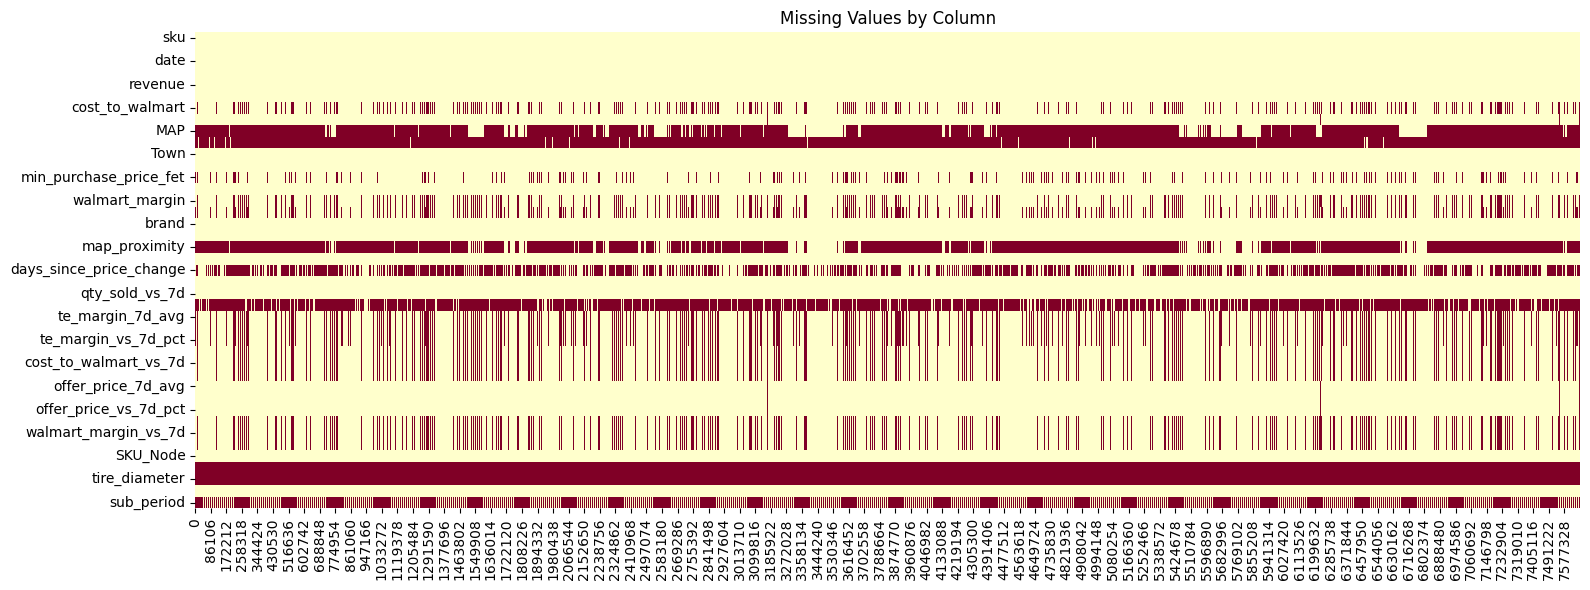

In [25]:
# Missing values heatmap
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(df.isnull().T, cbar=False, cmap="YlOrRd", ax=ax)
ax.set_title("Missing Values by Column")
plt.tight_layout()
plt.show()

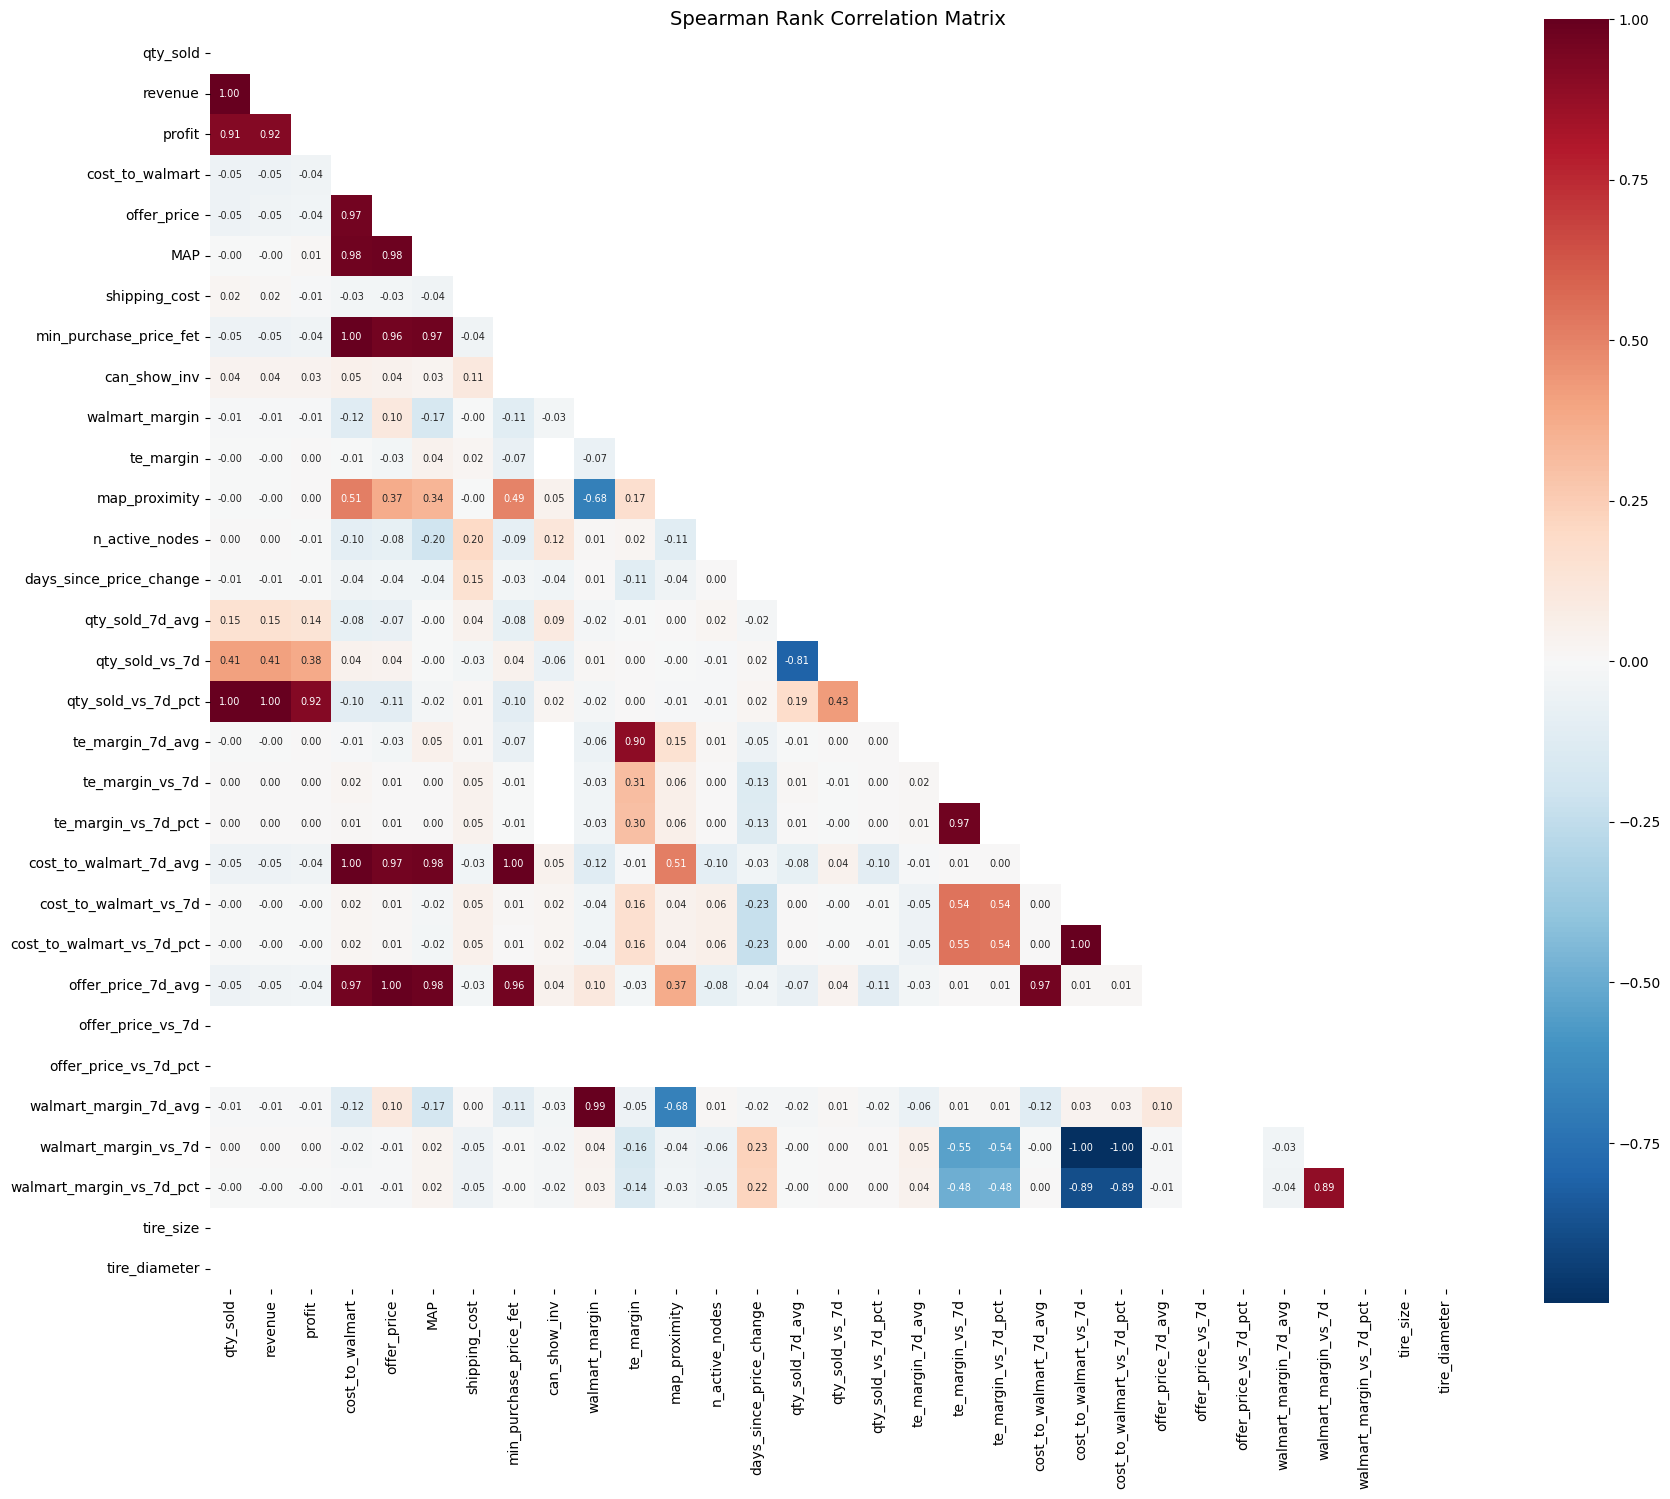

In [26]:
# Spearman correlation matrix (full numeric columns)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID-like columns
numeric_cols = [c for c in numeric_cols if c not in ["day_of_week"]]

corr_matrix = df[numeric_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, ax=ax,
    annot_kws={"size": 7}, square=True,
)
ax.set_title("Spearman Rank Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

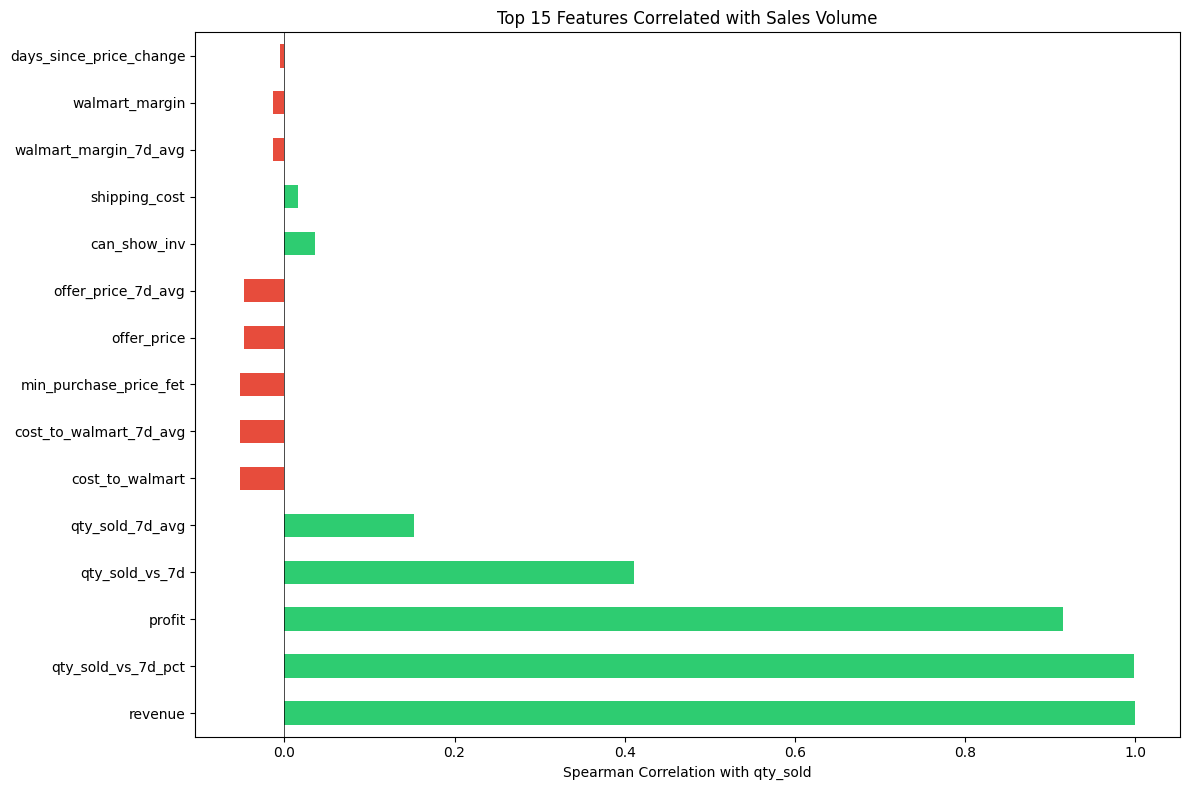


Top 15 correlations with qty_sold:
revenue                    0.999955
qty_sold_vs_7d_pct         0.998146
profit                     0.914567
qty_sold_vs_7d             0.410947
qty_sold_7d_avg            0.151978
cost_to_walmart           -0.052094
cost_to_walmart_7d_avg    -0.051987
min_purchase_price_fet    -0.051882
offer_price               -0.047585
offer_price_7d_avg        -0.047585
can_show_inv               0.036053
shipping_cost              0.015729
walmart_margin_7d_avg     -0.013659
walmart_margin            -0.013205
days_since_price_change   -0.005269


In [27]:
# Top correlations with qty_sold
target_corrs = (
    corr_matrix["qty_sold"]
    .drop("qty_sold")
    .dropna()
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corrs.head(15)]
target_corrs.head(15).plot.barh(ax=ax, color=colors)
ax.set_xlabel("Spearman Correlation with qty_sold")
ax.set_title("Top 15 Features Correlated with Sales Volume")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nTop 15 correlations with qty_sold:")
print(target_corrs.head(15).to_string())

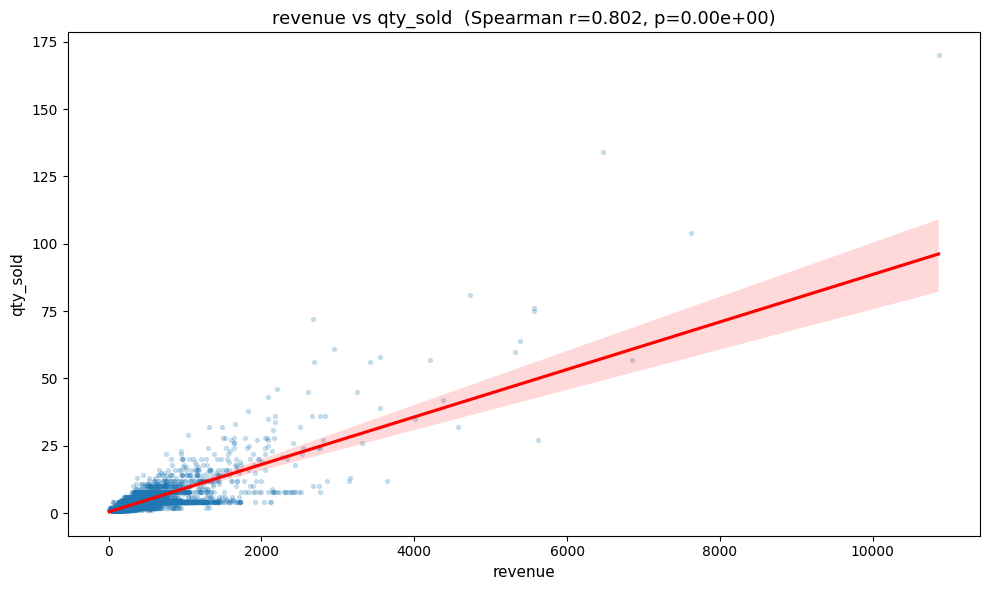

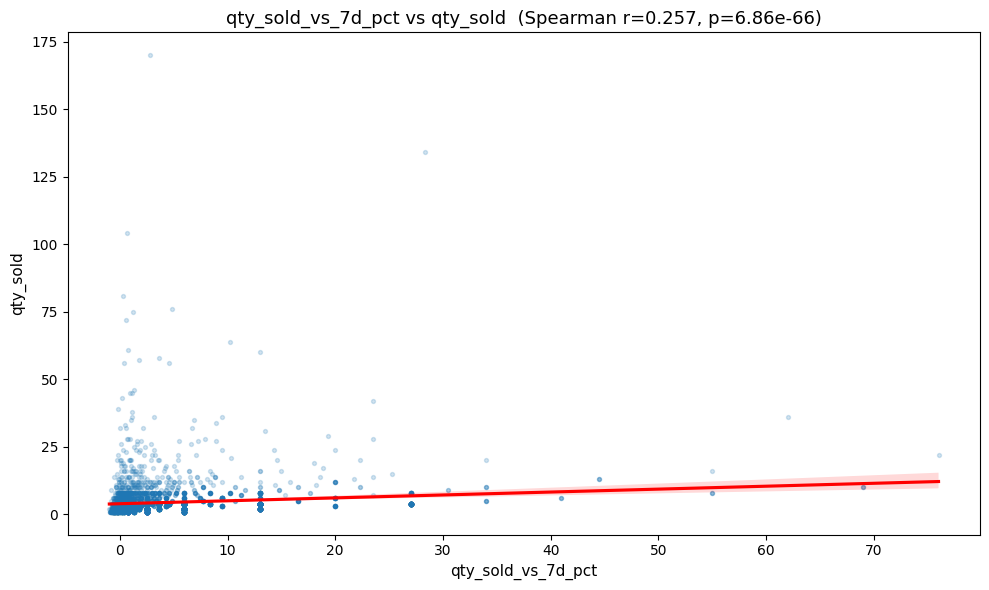

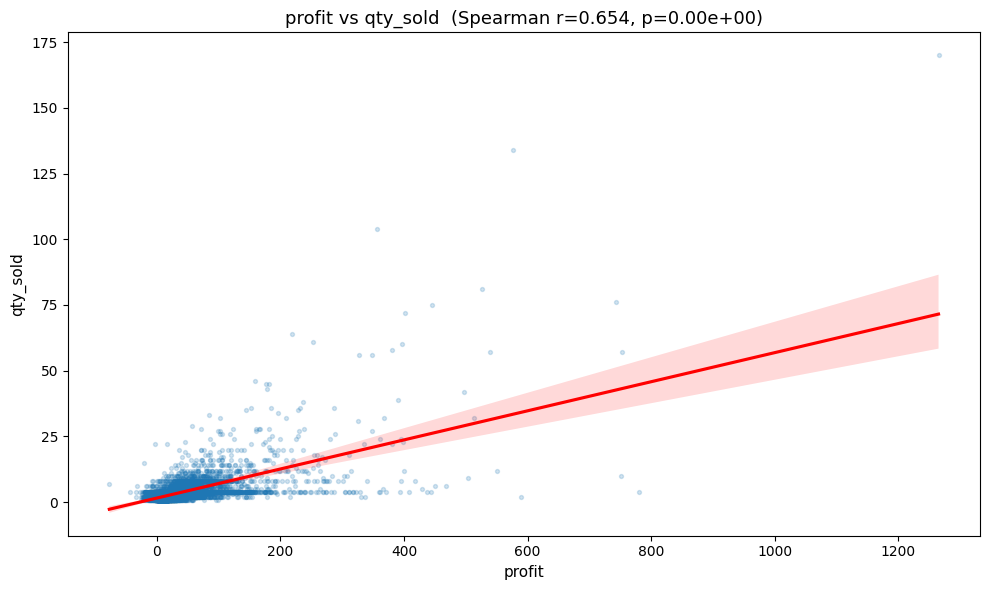

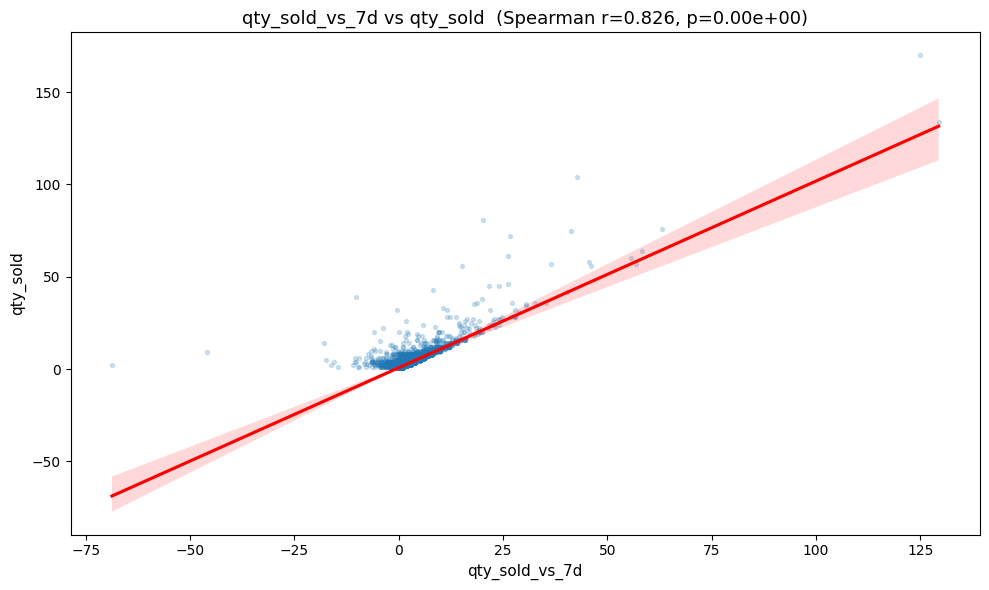

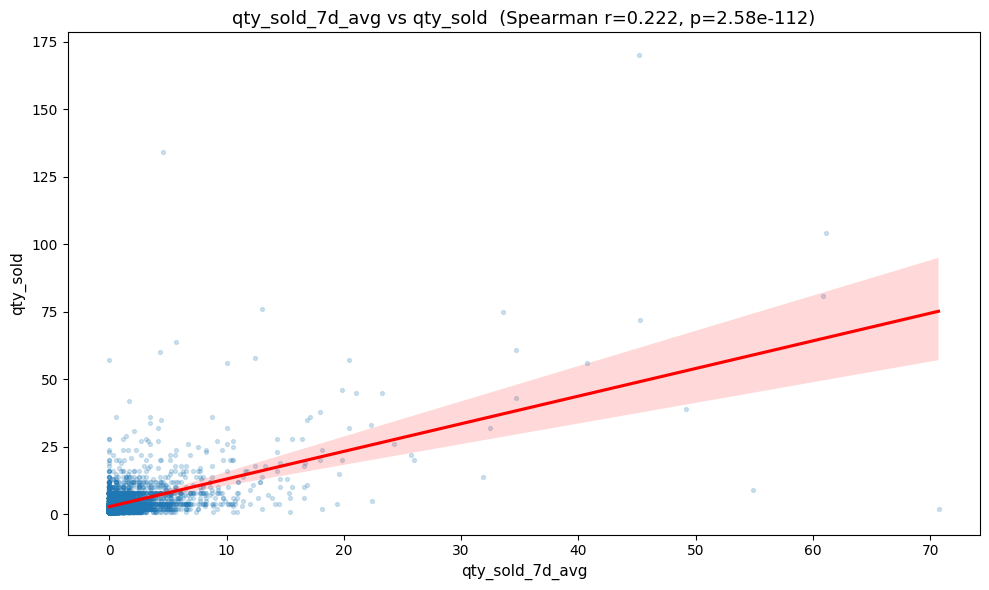

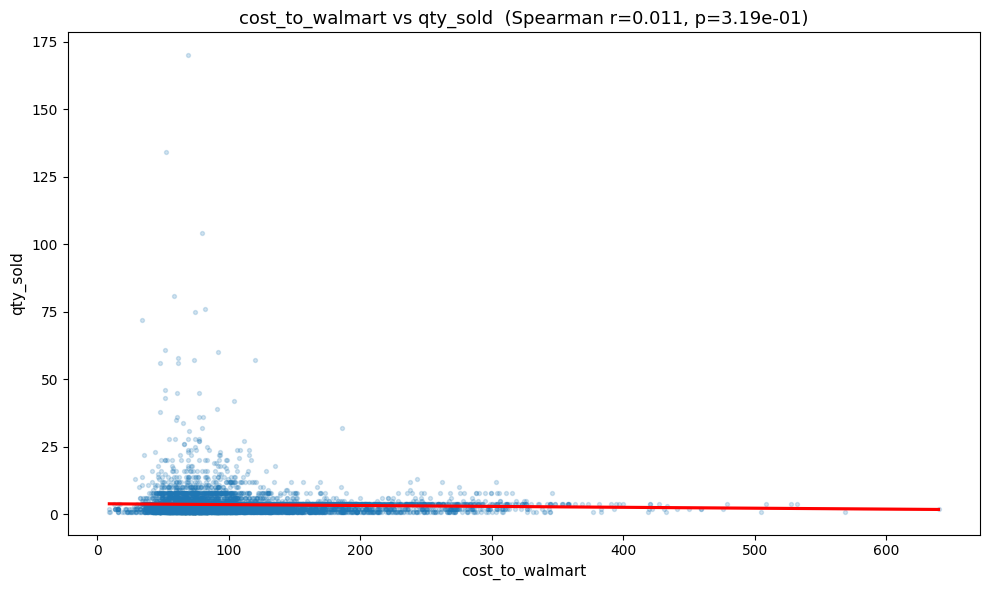

In [28]:
# Scatter plots for top 6 correlated features (individual figures for clarity)
top_features = target_corrs.head(6).index.tolist()

# Sample for performance
df_nonzero = df[df["qty_sold"] > 0]
df_sample = df_nonzero.sample(n=min(10000, len(df_nonzero)), random_state=42)

for col in top_features:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.regplot(
        data=df_sample, x=col, y="qty_sold", ax=ax,
        scatter_kws={"alpha": 0.2, "s": 8}, line_kws={"color": "red"},
    )
    valid = df_sample[[col, "qty_sold"]].dropna()
    r, p = stats.spearmanr(valid[col], valid["qty_sold"])
    ax.set_title(f"{col} vs qty_sold  (Spearman r={r:.3f}, p={p:.2e})", fontsize=13)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("qty_sold", fontsize=11)
    plt.tight_layout()
    plt.show()


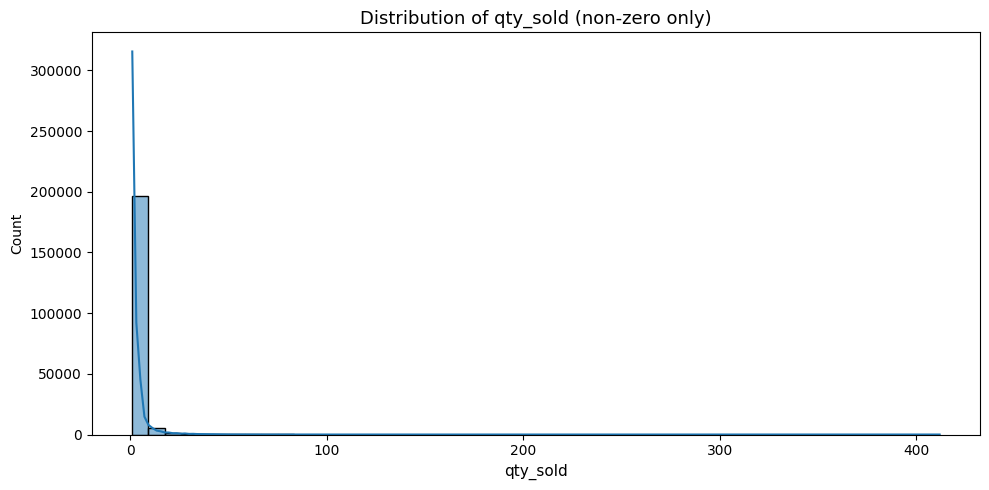

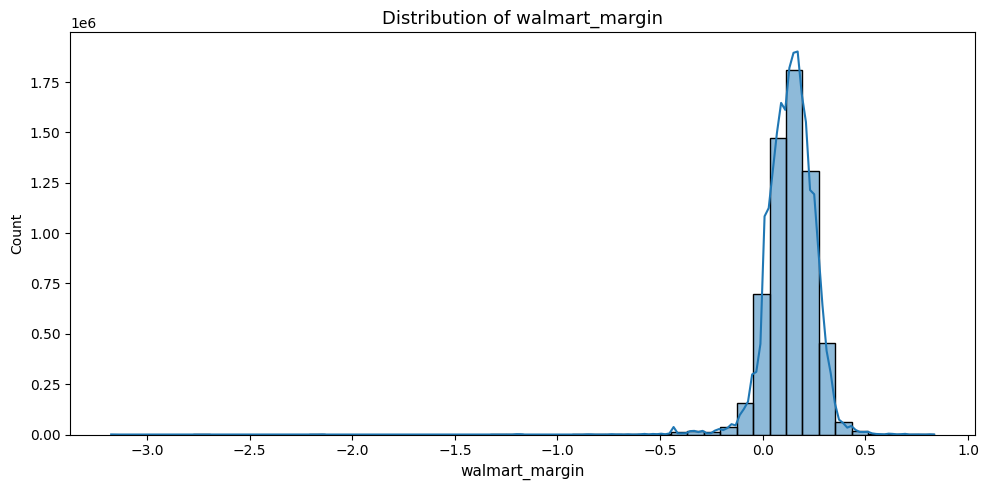

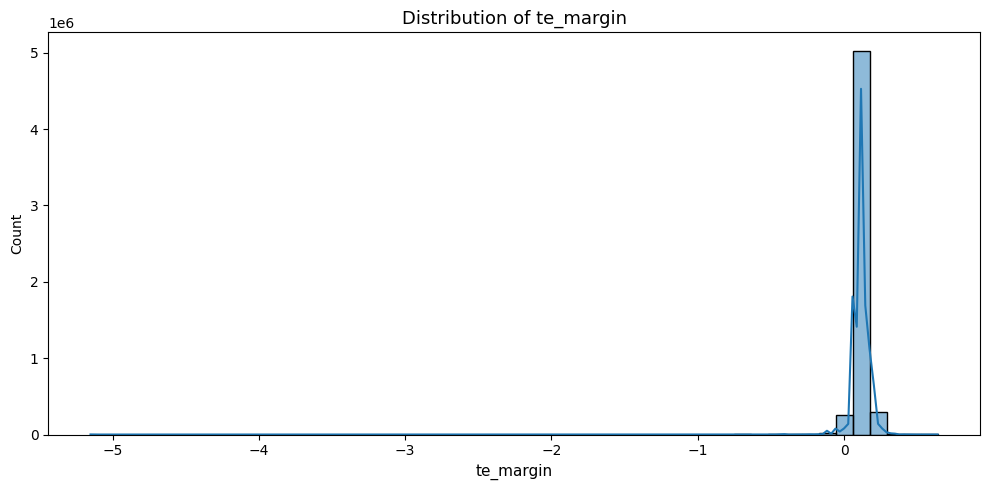

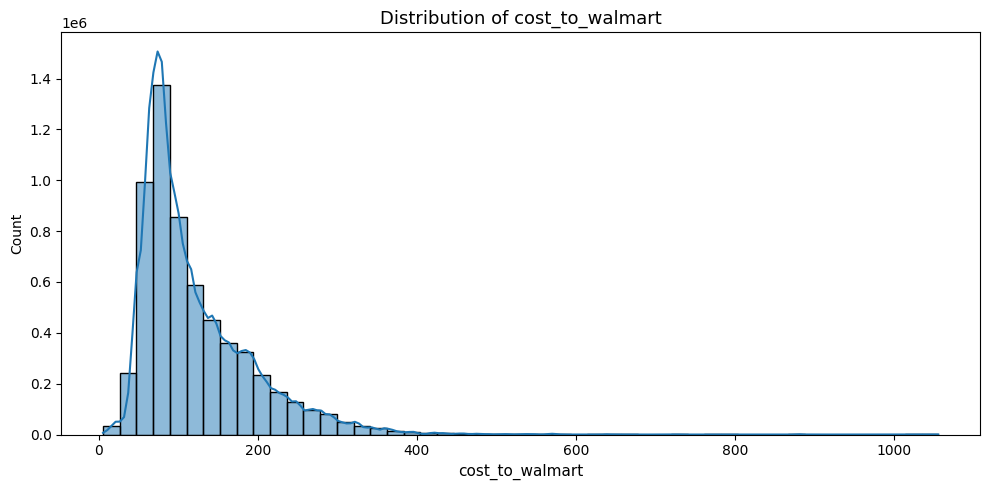

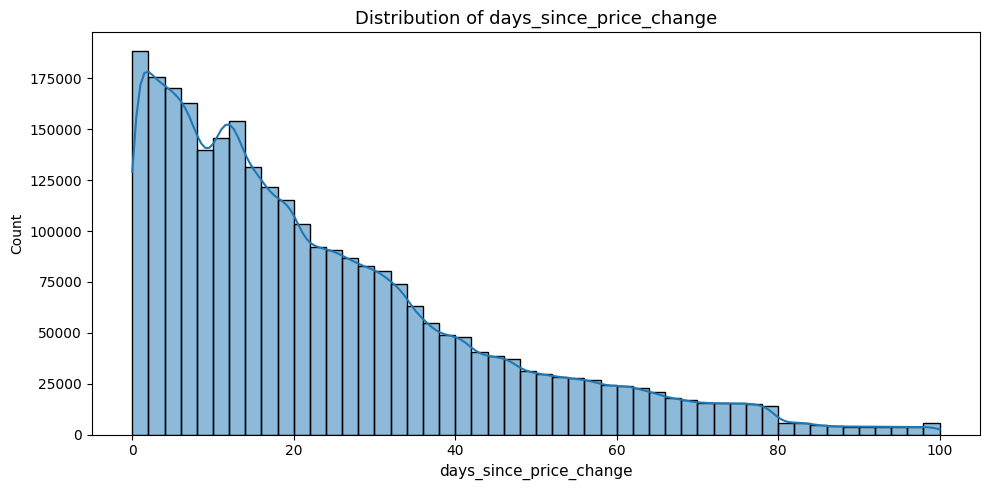

In [29]:
# Distribution plots for key variables (individual figures)
dist_cols = ["qty_sold", "walmart_margin", "te_margin", "cost_to_walmart", "days_since_price_change"]
dist_cols = [c for c in dist_cols if c in df.columns]

for col in dist_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    data = df[col].dropna()
    if col == "qty_sold":
        data = data[data > 0]  # Skip zeros for visibility
        ax.set_title(f"Distribution of {col} (non-zero only)", fontsize=13)
    else:
        ax.set_title(f"Distribution of {col}", fontsize=13)
    sns.histplot(data, ax=ax, bins=50, kde=True)
    ax.set_xlabel(col, fontsize=11)
    plt.tight_layout()
    plt.show()


## 12. Statistical Tests

In [30]:
# Test 1: Price change impact on sales
# Compare qty_sold on days with a recent price change (<=3 days) vs no change (>7 days)
recent_change = df[df["days_since_price_change"] <= 3]["qty_sold"]
no_change = df[df["days_since_price_change"] > 7]["qty_sold"]

if len(recent_change) > 0 and len(no_change) > 0:
    stat, pval = stats.mannwhitneyu(recent_change, no_change, alternative="two-sided")
    print("=== Price Change Impact on Sales ===")
    print(f"Recent change (<=3 days): n={len(recent_change):,}, mean={recent_change.mean():.3f}, median={recent_change.median():.1f}")
    print(f"No recent change (>7 days): n={len(no_change):,}, mean={no_change.mean():.3f}, median={no_change.median():.1f}")
    print(f"Mann-Whitney U stat={stat:.0f}, p-value={pval:.4e}")
    print(f"Significant at 5%: {'Yes' if pval < 0.05 else 'No'}")
else:
    print("Insufficient data for price change analysis")

=== Price Change Impact on Sales ===
Recent change (<=3 days): n=364,076, mean=0.101, median=0.0
No recent change (>7 days): n=2,141,490, mean=0.100, median=0.0
Mann-Whitney U stat=391008388952, p-value=7.3350e-25
Significant at 5%: Yes


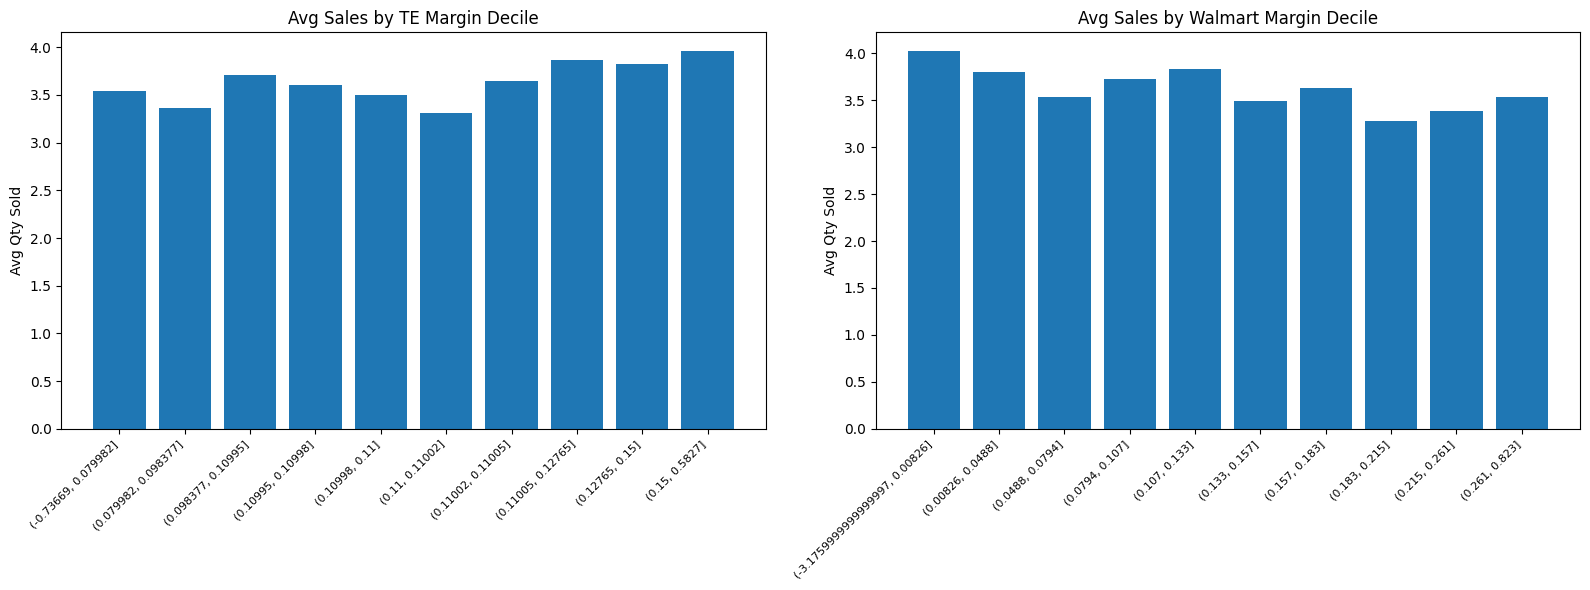

In [31]:
# Test 2: Margin level vs. revenue
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, label in zip(axes, ["te_margin", "walmart_margin"], ["TE Margin", "Walmart Margin"]):
    df_valid = df[df[col].notna() & (df["qty_sold"] > 0)].copy()
    if len(df_valid) > 100:
        df_valid["margin_bin"] = pd.qcut(df_valid[col], 10, duplicates="drop")
        margin_revenue = (
            df_valid.groupby("margin_bin", observed=True)
            .agg(avg_qty=("qty_sold", "mean"), total_qty=("qty_sold", "sum"), count=("qty_sold", "count"))
            .reset_index()
        )
        margin_revenue["margin_bin"] = margin_revenue["margin_bin"].astype(str)
        ax.bar(range(len(margin_revenue)), margin_revenue["avg_qty"])
        ax.set_xticks(range(len(margin_revenue)))
        ax.set_xticklabels(margin_revenue["margin_bin"], rotation=45, ha="right", fontsize=8)
        ax.set_ylabel("Avg Qty Sold")
        ax.set_title(f"Avg Sales by {label} Decile")
    else:
        ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center", transform=ax.transAxes)

plt.tight_layout()
plt.show()

In [32]:
# Test 3: Inventory availability vs sales
inv_yes = df[df["can_show_inv"] == 1]["qty_sold"]
inv_no = df[df["can_show_inv"] == 0]["qty_sold"]

print("=== Inventory Availability vs Sales ===")
print(f"With inventory:    n={len(inv_yes):,}, mean={inv_yes.mean():.3f}, median={inv_yes.median():.1f}")
print(f"Without inventory: n={len(inv_no):,}, mean={inv_no.mean():.3f}, median={inv_no.median():.1f}")

if len(inv_yes) > 0 and len(inv_no) > 0:
    stat, pval = stats.mannwhitneyu(inv_yes, inv_no, alternative="two-sided")
    print(f"Mann-Whitney U stat={stat:.0f}, p-value={pval:.4e}")
    print(f"Significant at 5%: {'Yes' if pval < 0.05 else 'No'}")

=== Inventory Availability vs Sales ===
With inventory:    n=6,482,089, mean=0.108, median=0.0
Without inventory: n=1,181,321, mean=0.046, median=0.0


Mann-Whitney U stat=3890297933914, p-value=0.0000e+00
Significant at 5%: Yes


In [33]:
# Test 4: OLS regression
import statsmodels.api as sm

feature_cols = [
    "cost_to_walmart", "offer_price", "walmart_margin", "te_margin",
    "can_show_inv", "shipping_cost", "n_active_nodes", "day_of_week",
    "days_since_price_change",
]
feature_cols = [c for c in feature_cols if c in df.columns]

df_reg = df[feature_cols + ["qty_sold"]].dropna()

if len(df_reg) > 100:
    X = sm.add_constant(df_reg[feature_cols])
    y = df_reg["qty_sold"]
    model = sm.OLS(y, X).fit()
    print(model.summary())
else:
    print("Insufficient data for OLS regression")

                            OLS Regression Results                            
Dep. Variable:               qty_sold   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     16.98
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           1.94e-25
Time:                        19:31:43   Log-Likelihood:                -40539.
No. Observations:               38982   AIC:                         8.110e+04
Df Residuals:                   38973   BIC:                         8.117e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
cost_to_walmart           

In [34]:
# Also run with log-transformed qty_sold (to handle zero-inflation)
df_reg_log = df_reg[df_reg["qty_sold"] > 0].copy()
if len(df_reg_log) > 100:
    X_log = sm.add_constant(df_reg_log[feature_cols])
    y_log = np.log1p(df_reg_log["qty_sold"])
    model_log = sm.OLS(y_log, X_log).fit()
    print("=== OLS with log(1 + qty_sold), non-zero sales only ===")
    print(model_log.summary())
else:
    print("Insufficient non-zero sales data for log OLS")

=== OLS with log(1 + qty_sold), non-zero sales only ===
                            OLS Regression Results                            
Dep. Variable:               qty_sold   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     4.324
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           3.76e-05
Time:                        19:31:43   Log-Likelihood:                -681.67
No. Observations:                1208   AIC:                             1381.
Df Residuals:                    1199   BIC:                             1427.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

### Test 5: Price Change Impact on Revenue

Study the correlation between Walmart price changes and revenue directly,
complementing the qty-based analysis in Test 1.

In [35]:
# Price Change Impact on Revenue
if "revenue" in df.columns and "cost_to_walmart_pct_chg" in df.columns:
    df_pc = df[df["cost_to_walmart_pct_chg"].notna() & df["revenue"].notna()].copy()
    df_pc = df_pc[df_pc["cost_to_walmart_pct_chg"] != 0]

    if len(df_pc) > 50:
        from scipy.stats import spearmanr, pearsonr, mannwhitneyu

        r_pearson, p_pearson = pearsonr(df_pc["cost_to_walmart_pct_chg"], df_pc["revenue"])
        r_spearman, p_spearman = spearmanr(df_pc["cost_to_walmart_pct_chg"], df_pc["revenue"])
        print("=== Price Change vs Revenue Correlation ===")
        print(f"Pearson  r = {r_pearson:.4f}  (p = {p_pearson:.4g})")
        print(f"Spearman r = {r_spearman:.4f}  (p = {p_spearman:.4g})")

        # Bucketed analysis
        df_pc["price_change_bucket"] = pd.cut(
            df_pc["cost_to_walmart_pct_chg"],
            bins=[-np.inf, -0.05, -0.01, 0.01, 0.05, np.inf],
            labels=["Large decrease (<-5%)", "Small decrease (-5% to -1%)",
                    "Minimal (-1% to 1%)", "Small increase (1% to 5%)",
                    "Large increase (>5%)"],
        )
        bucket_stats = (
            df_pc.groupby("price_change_bucket", observed=True)
            .agg(n=("revenue", "size"), mean_revenue=("revenue", "mean"),
                 median_revenue=("revenue", "median"), total_revenue=("revenue", "sum"),
                 mean_qty=("qty_sold", "mean"))
            .round(2)
        )
        print()
        print("=== Revenue by Price Change Bucket ===")
        print(bucket_stats.to_string())

        # Visualization
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].scatter(df_pc["cost_to_walmart_pct_chg"] * 100, df_pc["revenue"], alpha=0.15, s=8)
        axes[0].set_xlabel("Price Change (%)")
        axes[0].set_ylabel("Revenue ($)")
        axes[0].set_title(f"Price Change vs Revenue (r={r_spearman:.3f})")
        axes[0].axvline(0, color="red", linestyle="--", alpha=0.5)

        bucket_stats["mean_revenue"].plot(kind="bar", ax=axes[1], color="steelblue", alpha=0.8)
        axes[1].set_ylabel("Mean Revenue ($)")
        axes[1].set_title("Mean Revenue by Price Change Bucket")
        axes[1].tick_params(axis="x", rotation=30)

        bucket_stats["mean_qty"].plot(kind="bar", ax=axes[2], color="darkorange", alpha=0.8)
        axes[2].set_ylabel("Mean Qty Sold")
        axes[2].set_title("Mean Qty by Price Change Bucket")
        axes[2].tick_params(axis="x", rotation=30)
        plt.tight_layout()
        plt.show()

        # Pre/post revenue around price change events
        print()
        print("=== Pre/Post Revenue Around Price Change Events ===")
        df_events = df[df["days_since_price_change"].notna()].copy()
        pre_rev = df_events[df_events["days_since_price_change"].between(4, 7)]["revenue"]
        post_rev = df_events[df_events["days_since_price_change"].between(0, 3)]["revenue"]
        print(f"Pre-change (4-7 days before):  n={len(pre_rev):,}, mean=${pre_rev.mean():.2f}")
        print(f"Post-change (0-3 days after):  n={len(post_rev):,}, mean=${post_rev.mean():.2f}")
        if len(pre_rev) > 30 and len(post_rev) > 30:
            stat, pval = mannwhitneyu(post_rev, pre_rev, alternative="two-sided")
            print(f"Mann-Whitney U test: stat={stat:.1f}, p={pval:.4g}")
            pct_change = (post_rev.mean() - pre_rev.mean()) / pre_rev.mean() * 100
            print(f"Revenue change: {pct_change:+.1f}%")
    else:
        print(f"Insufficient price-change rows ({len(df_pc)}) for revenue correlation analysis")
else:
    missing = [c for c in ["revenue", "cost_to_walmart_pct_chg"] if c not in df.columns]
    print(f"Columns missing for price-revenue analysis: {missing}")


Columns missing for price-revenue analysis: ['cost_to_walmart_pct_chg']


## 13. Geographic & Brand Analysis

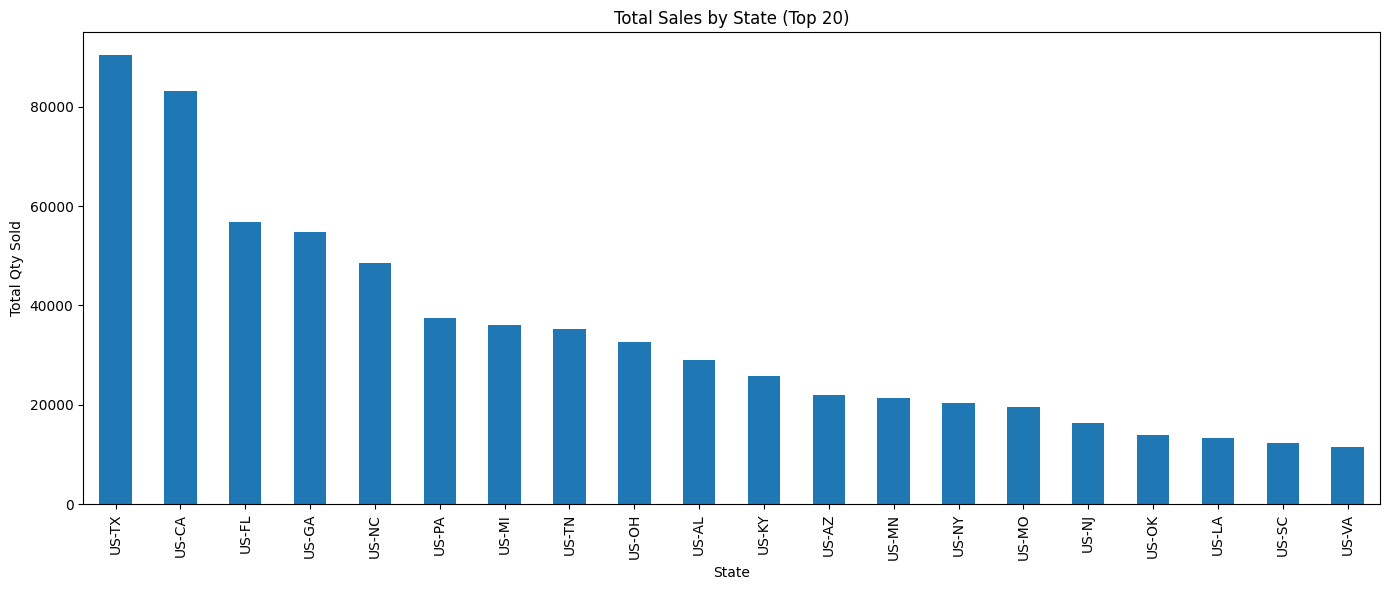

,total_qty,avg_wm_margin,avg_te_margin,n_nodes
State,,,,
US-TX,90493.0,0.139243,0.111717,121
US-CA,83193.0,0.133796,0.113178,117
US-FL,56768.0,0.135216,0.112516,91
US-GA,54877.0,0.127190,0.108966,57
US-NC,48510.0,0.114920,0.112756,61
US-PA,37441.0,0.154482,0.109894,39
US-MI,36113.0,0.152677,0.116096,34
US-TN,35288.0,0.141099,0.113223,49
US-OH,32559.0,0.138820,0.113642,49


In [36]:
# Sales by state
state_sales = (
    df.groupby("State")
    .agg(
        total_qty=("qty_sold", "sum"),
        avg_wm_margin=("walmart_margin", "mean"),
        avg_te_margin=("te_margin", "mean"),
        n_nodes=("node", "nunique"),
    )
    .sort_values("total_qty", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(14, 6))
state_sales["total_qty"].plot.bar(ax=ax)
ax.set_title("Total Sales by State (Top 20)")
ax.set_ylabel("Total Qty Sold")
ax.set_xlabel("State")
plt.tight_layout()
plt.show()

state_sales

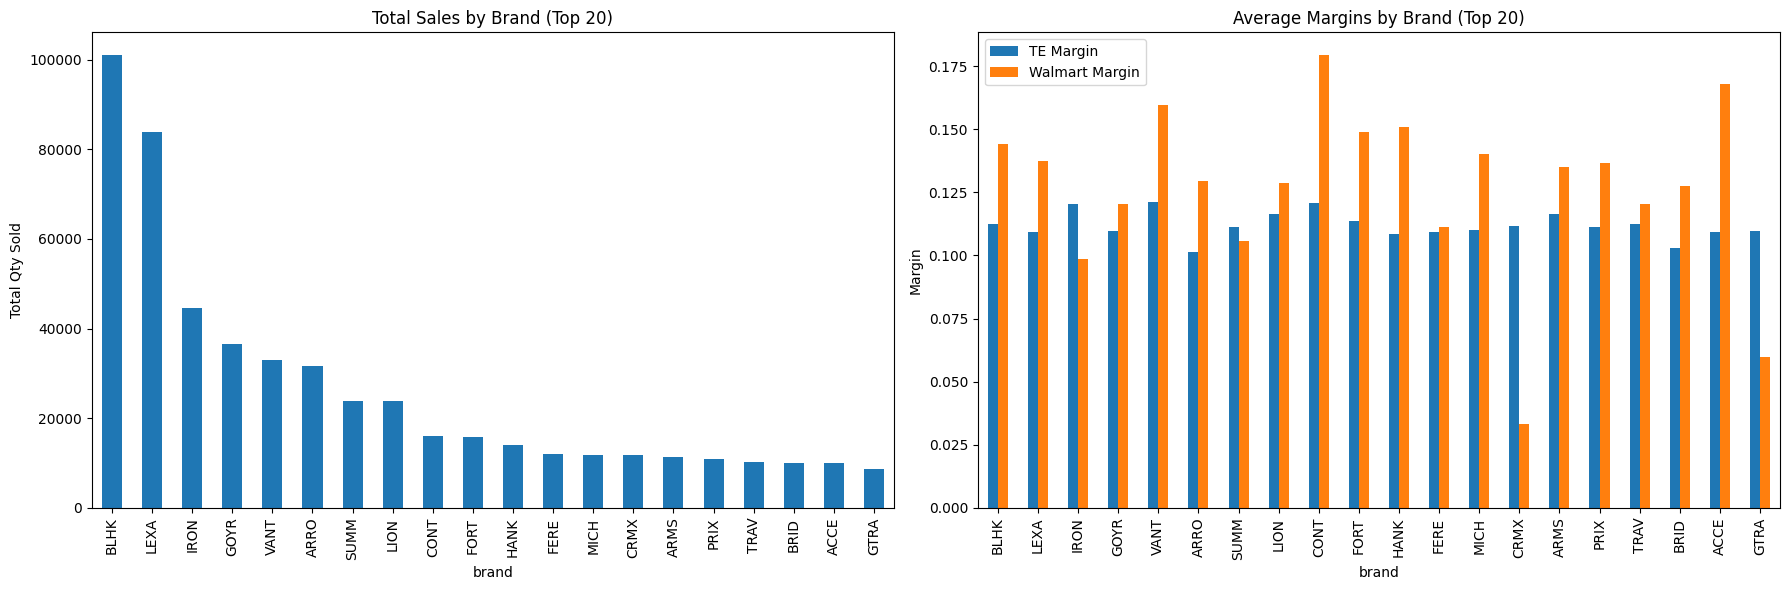

,total_qty,total_revenue,avg_te_margin,avg_wm_margin,n_skus,n_nodes
brand,,,,,,
BLHK,101020.0,8961516.40,0.112434,0.144085,250,70
LEXA,83839.0,6929443.87,0.109218,0.137503,288,107
IRON,44525.0,3343287.24,0.120280,0.098541,161,384
GOYR,36574.0,6096851.32,0.109690,0.120276,290,555
VANT,32900.0,2243233.39,0.121200,0.159762,63,378
ARRO,31543.0,2529052.03,0.101249,0.129292,191,77
SUMM,23921.0,2184388.27,0.111386,0.105721,156,28
LION,23756.0,1660727.52,0.116480,0.128626,152,84
CONT,15954.0,2418318.92,0.120653,0.179407,160,502


In [37]:
# Brand-level analysis
brand_analysis = (
    df.groupby("brand")
    .agg(
        total_qty=("qty_sold", "sum"),
        total_revenue=("revenue", "sum"),
        avg_te_margin=("te_margin", "mean"),
        avg_wm_margin=("walmart_margin", "mean"),
        n_skus=("sku", "nunique"),
        n_nodes=("node", "nunique"),
    )
    .sort_values("total_qty", ascending=False)
    .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

brand_analysis["total_qty"].plot.bar(ax=axes[0])
axes[0].set_title("Total Sales by Brand (Top 20)")
axes[0].set_ylabel("Total Qty Sold")

brand_analysis[["avg_te_margin", "avg_wm_margin"]].plot.bar(ax=axes[1])
axes[1].set_title("Average Margins by Brand (Top 20)")
axes[1].set_ylabel("Margin")
axes[1].legend(["TE Margin", "Walmart Margin"])

plt.tight_layout()
plt.show()

brand_analysis

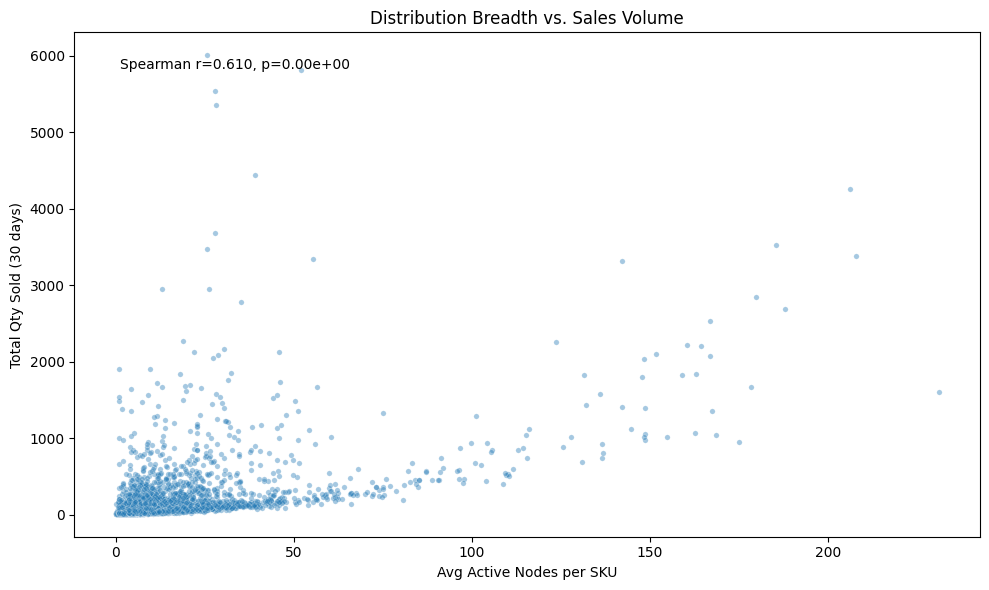

In [38]:
# Node distribution breadth vs sales
breadth = (
    df.groupby("sku")
    .agg(
        avg_active_nodes=("n_active_nodes", "mean"),
        total_qty=("qty_sold", "sum"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=breadth, x="avg_active_nodes", y="total_qty", alpha=0.4, s=15, ax=ax)
ax.set_xlabel("Avg Active Nodes per SKU")
ax.set_ylabel("Total Qty Sold (30 days)")
ax.set_title("Distribution Breadth vs. Sales Volume")

r, p = stats.spearmanr(breadth["avg_active_nodes"], breadth["total_qty"])
ax.text(0.05, 0.95, f"Spearman r={r:.3f}, p={p:.2e}", transform=ax.transAxes, va="top")

plt.tight_layout()
plt.show()

## 14. Summary & Cleanup

### Key Findings

*(Fill in after running the analysis)*

1. **Price change impact:** ...
2. **Top correlated features:** ...
3. **Margin sweet spots:** ...
4. **Inventory availability effect:** ...
5. **Geographic patterns:** ...
6. **Brand insights:** ...
7. **Distribution breadth:** ...

## 15. Extended Feature Engineering

Add tire size (from item report) and MAP tire flag to the dataset.

In [39]:
# --- Schema inspection (DW unavailable — using cached data) ---
# The DW at 10.1.0.54 is unreachable from this environment.
# The item report query is: SELECT * FROM pricing_tests.walmart_item_report
# SIZE_COLUMN cannot be auto-detected without DW access.
# When DW is available, run the original cell to discover the tire size column.

SIZE_COLUMN = None
print("DW unavailable — SIZE_COLUMN set to None.")
print("Tire size features will use placeholders.")
print("Re-run this cell when DW access is restored to discover the column.")


DW unavailable — SIZE_COLUMN set to None.
Tire size features will use placeholders.
Re-run this cell when DW access is restored to discover the column.


In [40]:
# --- Load tire size & create is_MAP_tire flag ---
import re as _re

# Set SIZE_COLUMN after inspecting the schema above
# SIZE_COLUMN = "product_name"  # <-- adjust to the correct column name

if SIZE_COLUMN is not None:
    size_query = f"""
        SELECT product_code AS "Product Code", {SIZE_COLUMN} AS raw_size
        FROM pricing_tests.walmart_item_report
        WHERE date = (SELECT MAX(date) FROM pricing_tests.walmart_item_report
                      WHERE date <= '{END_DATE}')
          AND "1p_offer_status" = 'PUBLISHED'
    """
    try:
        df_size = loader.dw.run_query(size_query, new_credentials=True)
        df_size = df_size.drop_duplicates(subset=["Product Code"])

        # Extract tire diameter from patterns like 205/55R16, LT265/70R17, 16", etc.
        df_size["tire_diameter"] = (
            df_size["raw_size"]
            .astype(str)
            .str.extract(r"[Rr](\d{2,3})")[0]
            .astype(float)
        )
        df_size["tire_size"] = df_size["raw_size"]

        df = df.merge(
            df_size[["Product Code", "tire_size", "tire_diameter"]],
            left_on="sku", right_on="Product Code", how="left",
        )
        if "Product Code_y" in df.columns:
            df.drop(columns=[c for c in df.columns if c.endswith("_y")], inplace=True)
            df.rename(columns={c: c.replace("_x", "") for c in df.columns if c.endswith("_x")}, inplace=True)

        print(f"Tire size coverage: {df['tire_size'].notna().mean():.1%}")
        print(f"Tire diameter distribution:\n{df['tire_diameter'].value_counts().head(10)}")
    except Exception as e:
        print(f"Tire size load failed: {e}")
        df["tire_size"] = np.nan
        df["tire_diameter"] = np.nan
else:
    print("SIZE_COLUMN not set — skipping tire size. Set it above and re-run.")
    df["tire_size"] = np.nan
    df["tire_diameter"] = np.nan

# MAP tire flag: True if the SKU has a MAP price (minimum allowed price)
df["is_MAP_tire"] = df["MAP"].notna()
print(f"\nMAP tire distribution:\n{df['is_MAP_tire'].value_counts()}")
print(f"MAP tire %: {df['is_MAP_tire'].mean():.1%}")


SIZE_COLUMN not set — skipping tire size. Set it above and re-run.

MAP tire distribution:
is_MAP_tire
False    6165360
True     1498050
Name: count, dtype: int64
MAP tire %: 19.5%


## 16. Price Elasticity by State & Brand-State

Estimate price elasticity at the state and brand-state level using log-log OLS:
`log(qty+1) ~ log(offer_price)`

Elasticity < 0 means higher price → lower sales (expected). More negative = more price-sensitive.

States with valid elasticity estimates: 46


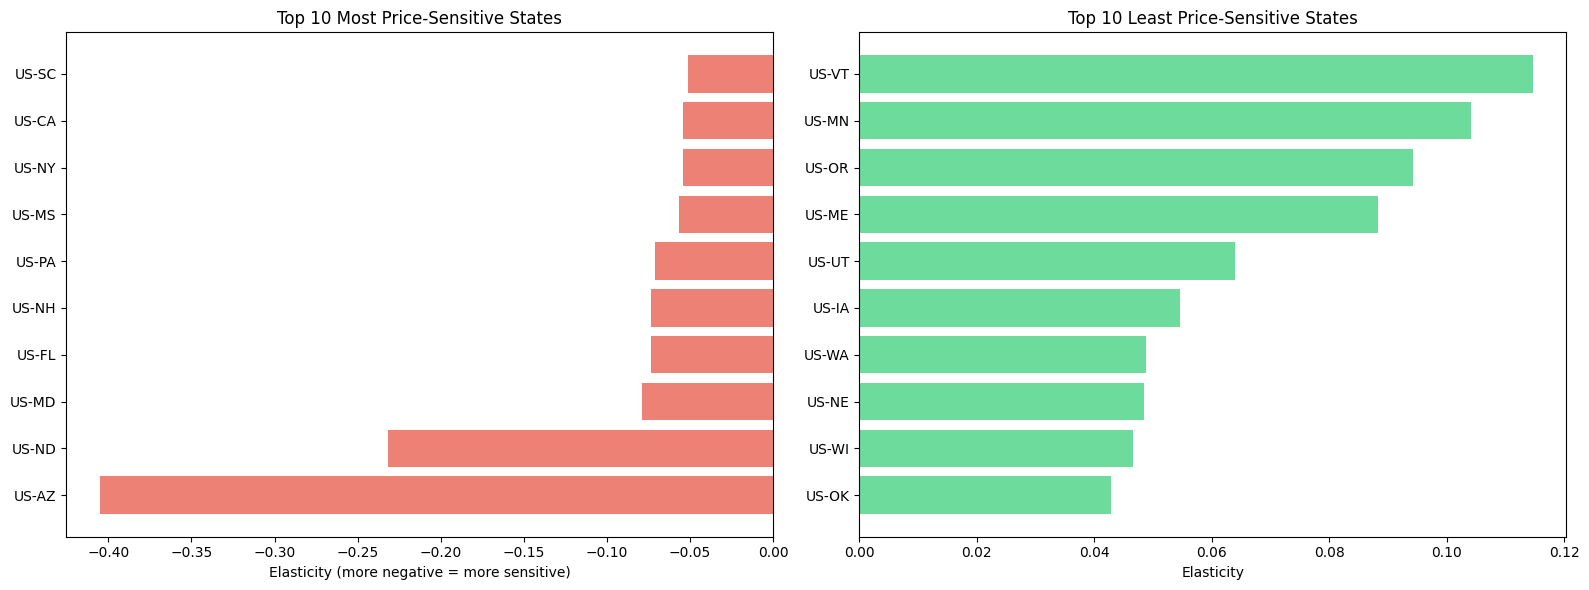

,State,elasticity,SE,p_value,n_obs,ci_lower,ci_upper
2,US-AZ,-0.4051,0.0201,0.0000,3626,-0.4444,-0.3657
24,US-ND,-0.2319,0.0927,0.0142,93,-0.4136,-0.0502
16,US-MD,-0.0790,0.0220,0.0004,1416,-0.1221,-0.0358
6,US-FL,-0.0734,0.0087,0.0000,15160,-0.0904,-0.0565
26,US-NH,-0.0734,0.0505,0.1471,236,-0.1723,0.0255
34,US-PA,-0.0710,0.0147,0.0000,7807,-0.0999,-0.0422
21,US-MS,-0.0568,0.0213,0.0078,2711,-0.0987,-0.0150
30,US-NY,-0.0545,0.0142,0.0001,5527,-0.0825,-0.0266
3,US-CA,-0.0543,0.0077,0.0000,21455,-0.0694,-0.0392
35,US-SC,-0.0514,0.0180,0.0043,3438,-0.0867,-0.0162


In [41]:
# --- Elasticity by State ---
import statsmodels.api as sm

df_elast = df[(df["qty_sold"] > 0) & (df["offer_price"] > 0)].copy()

MIN_OBS_STATE = 50
state_elasticity = []

for state, grp in df_elast.groupby("State"):
    if pd.isna(state) or len(grp) < MIN_OBS_STATE:
        continue
    try:
        X = sm.add_constant(np.log(grp["offer_price"]))
        y = np.log1p(grp["qty_sold"])
        model = sm.OLS(y, X).fit()
        coef = model.params.iloc[-1]
        se = model.bse.iloc[-1]
        pval = model.pvalues.iloc[-1]
        state_elasticity.append({
            "State": state, "elasticity": coef, "SE": se, "p_value": pval,
            "n_obs": len(grp), "ci_lower": coef - 1.96 * se, "ci_upper": coef + 1.96 * se,
        })
    except Exception:
        continue

df_state_elast = pd.DataFrame(state_elasticity).sort_values("elasticity")
print(f"States with valid elasticity estimates: {len(df_state_elast)}")

# Bar chart: top/bottom 10
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_elastic = df_state_elast.head(10)
axes[0].barh(top_elastic["State"], top_elastic["elasticity"], color="#e74c3c", alpha=0.7)
axes[0].set_title("Top 10 Most Price-Sensitive States")
axes[0].set_xlabel("Elasticity (more negative = more sensitive)")

top_inelastic = df_state_elast.tail(10)
axes[1].barh(top_inelastic["State"], top_inelastic["elasticity"], color="#2ecc71", alpha=0.7)
axes[1].set_title("Top 10 Least Price-Sensitive States")
axes[1].set_xlabel("Elasticity")

plt.tight_layout()
plt.show()

display(df_state_elast.style.format({"elasticity": "{:.4f}", "SE": "{:.4f}", "p_value": "{:.4f}",
                                      "ci_lower": "{:.4f}", "ci_upper": "{:.4f}"}))


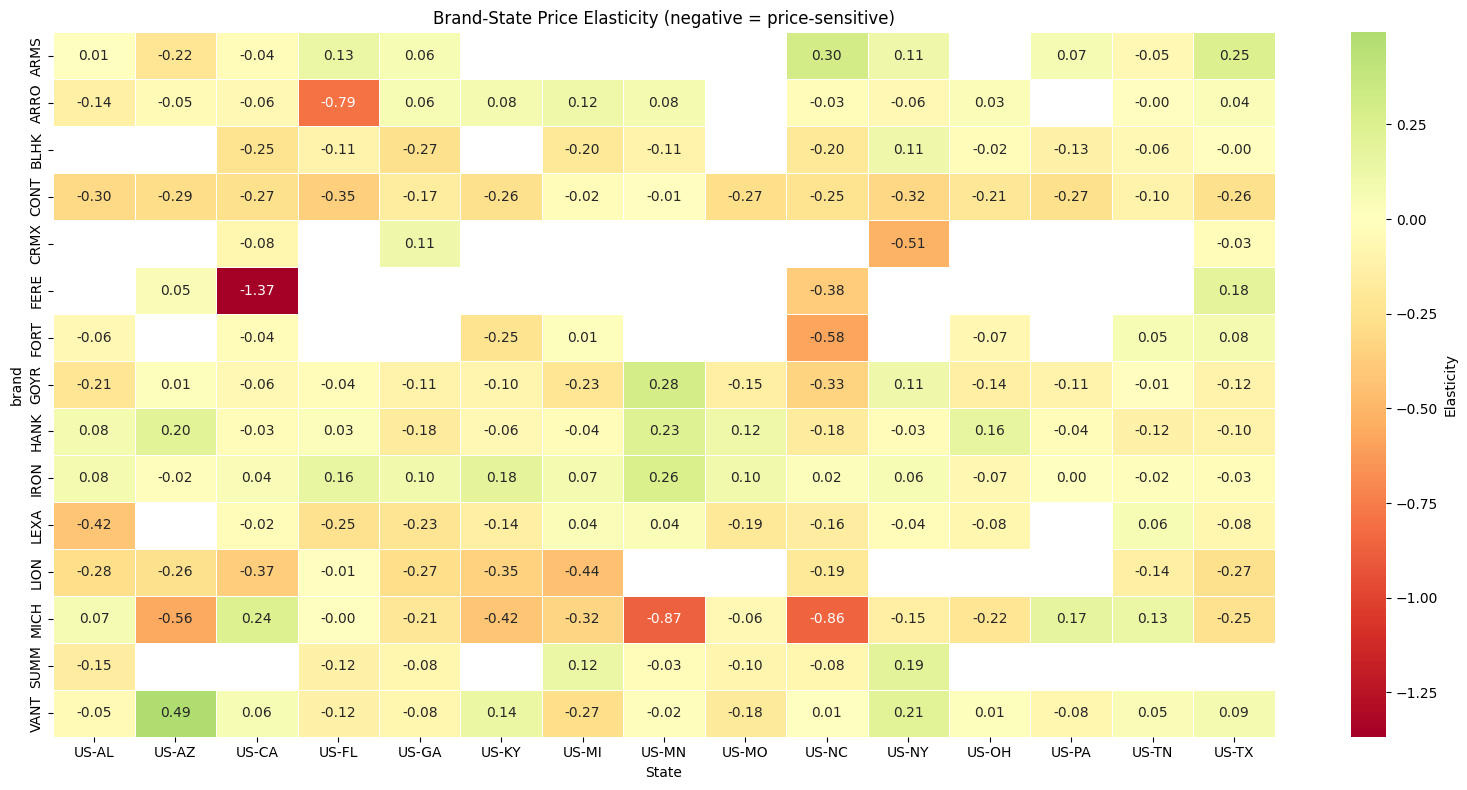


=== TOP 5 MOST PRICE-SENSITIVE Brand-State Segments ===
  FERE in US-CA: elasticity = -1.367*  (n=136)
  MICH in US-MN: elasticity = -0.871***  (n=173)
  MICH in US-NC: elasticity = -0.859***  (n=142)
  ARRO in US-FL: elasticity = -0.792***  (n=814)
  FORT in US-NC: elasticity = -0.582*  (n=77)

=== TOP 5 LEAST PRICE-SENSITIVE Brand-State Segments ===
  VANT in US-AZ: elasticity = 0.493*  (n=240)
  ARMS in US-NC: elasticity = 0.299  (n=43)
  GOYR in US-MN: elasticity = 0.283*  (n=409)
  IRON in US-MN: elasticity = 0.258**  (n=215)
  ARMS in US-TX: elasticity = 0.248***  (n=446)


In [42]:
# --- Brand-State Cross-Tabulation ---
MIN_OBS_BRAND_STATE = 30

top_brands_elast = df_elast.groupby("brand")["qty_sold"].sum().nlargest(15).index.tolist()
top_states_elast = df_elast.groupby("State")["qty_sold"].sum().nlargest(15).index.tolist()

brand_state_results = []
for brand in top_brands_elast:
    for state in top_states_elast:
        subset = df_elast[(df_elast["brand"] == brand) & (df_elast["State"] == state)]
        if len(subset) < MIN_OBS_BRAND_STATE:
            brand_state_results.append({"brand": brand, "State": state, "elasticity": np.nan,
                                         "n": len(subset), "p_value": np.nan})
            continue
        try:
            X = sm.add_constant(np.log(subset["offer_price"]))
            y = np.log1p(subset["qty_sold"])
            model = sm.OLS(y, X).fit()
            brand_state_results.append({
                "brand": brand, "State": state,
                "elasticity": model.params.iloc[-1],
                "n": len(subset), "p_value": model.pvalues.iloc[-1],
            })
        except Exception:
            brand_state_results.append({"brand": brand, "State": state, "elasticity": np.nan,
                                         "n": len(subset), "p_value": np.nan})

df_bs_elast = pd.DataFrame(brand_state_results)

# Pivot heatmap
pivot = df_bs_elast.pivot(index="brand", columns="State", values="elasticity")
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot, cmap="RdYlGn", center=0, annot=True, fmt=".2f",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Elasticity"})
ax.set_title("Brand-State Price Elasticity (negative = price-sensitive)")
plt.tight_layout()
plt.show()

# Narrative: top 5 most and least elastic segments
df_bs_valid = df_bs_elast.dropna(subset=["elasticity"])
most_elastic = df_bs_valid.nsmallest(5, "elasticity")
least_elastic = df_bs_valid.nlargest(5, "elasticity")

print("\n=== TOP 5 MOST PRICE-SENSITIVE Brand-State Segments ===")
for _, r in most_elastic.iterrows():
    sig = "***" if r["p_value"] < 0.001 else "**" if r["p_value"] < 0.01 else "*" if r["p_value"] < 0.05 else ""
    print(f"  {r['brand']} in {r['State']}: elasticity = {r['elasticity']:.3f}{sig}  (n={r['n']:,})")

print("\n=== TOP 5 LEAST PRICE-SENSITIVE Brand-State Segments ===")
for _, r in least_elastic.iterrows():
    sig = "***" if r["p_value"] < 0.001 else "**" if r["p_value"] < 0.01 else "*" if r["p_value"] < 0.05 else ""
    print(f"  {r['brand']} in {r['State']}: elasticity = {r['elasticity']:.3f}{sig}  (n={r['n']:,})")


In [43]:
# --- City-Level Drill-Down ---
MIN_OBS_CITY = 30
MIN_BRAND_STATE_FOR_CITY = 200

city_results = []
for brand in top_brands_elast:
    for state in top_states_elast:
        bs_subset = df_elast[(df_elast["brand"] == brand) & (df_elast["State"] == state)]
        if len(bs_subset) < MIN_BRAND_STATE_FOR_CITY:
            continue
        for city, city_grp in bs_subset.groupby("Town"):
            if pd.isna(city) or len(city_grp) < MIN_OBS_CITY:
                continue
            try:
                X = sm.add_constant(np.log(city_grp["offer_price"]))
                y = np.log1p(city_grp["qty_sold"])
                model = sm.OLS(y, X).fit()
                city_results.append({
                    "brand": brand, "State": state, "Town": city,
                    "elasticity": model.params.iloc[-1],
                    "n": len(city_grp), "p_value": model.pvalues.iloc[-1],
                })
            except Exception:
                continue

if city_results:
    df_city_elast = pd.DataFrame(city_results)
    # Show only brand-state combos with meaningful city-level variation
    city_var = df_city_elast.groupby(["brand", "State"])["elasticity"].std().reset_index()
    city_var = city_var.rename(columns={"elasticity": "elasticity_std"})
    notable = city_var[city_var["elasticity_std"] > 0.5]

    if len(notable) > 0:
        print(f"Brand-State segments with high city-level elasticity variation (std > 0.5): {len(notable)}")
        for _, r in notable.iterrows():
            cities = df_city_elast[(df_city_elast["brand"] == r["brand"]) & (df_city_elast["State"] == r["State"])]
            print(f"\n  {r['brand']} in {r['State']} (std={r['elasticity_std']:.2f}):")
            for _, c in cities.sort_values("elasticity").iterrows():
                sig = "*" if c["p_value"] < 0.05 else ""
                print(f"    {c['Town']:25s} elasticity={c['elasticity']:.3f}{sig} (n={c['n']:,})")
    else:
        print("No brand-state segments show meaningful city-level variation (std > 0.5).")
        print("City-level sample sizes may be too small for reliable estimates.")
else:
    print("Insufficient data for city-level elasticity estimates (need n>=30 per city).")


Brand-State segments with high city-level elasticity variation (std > 0.5): 4

  FORT in US-CA (std=0.55):
    Stockton                  elasticity=-0.737* (n=111)
    Fresno                    elasticity=-0.139 (n=59)
    Santa Ana                 elasticity=0.106 (n=164)
    Irwindale                 elasticity=0.146 (n=91)
    West Sacramento           elasticity=0.783* (n=46)

  GOYR in US-NC (std=0.62):
    Whiteville                elasticity=-1.164* (n=85)
    Morrisville               elasticity=-0.158 (n=127)
    Charlotte                 elasticity=-0.121 (n=218)
    GREENSBORO                elasticity=0.144 (n=37)
    Statesville               elasticity=0.486 (n=32)

  MICH in US-TX (std=0.70):
    Coppell                   elasticity=-0.935* (n=114)
    San Antonio               elasticity=0.252 (n=32)
    Houston                   elasticity=0.287 (n=54)

  VANT in US-AZ (std=0.70):
    Tucson                    elasticity=-0.232 (n=46)
    Phoenix                   elas

## 17. Heterogeneous Treatment Effects (DiD Decomposition)

Break down the Difference-in-Differences causal estimate by brand, price tier, state,
and MAP status to identify which segments are most/least affected by price changes.

In [44]:
# --- Build DiD Panel ---
# Identify treated SKU-Nodes (those with a price change) and matched controls

df_did = df[df["days_since_price_change"].notna()].copy()

# SKU_Node key
if "SKU_Node" not in df_did.columns:
    df_did["SKU_Node"] = df_did["sku"] + "-" + df_did["node"].astype(str)
if "SKU_Node" not in df.columns:
    df["SKU_Node"] = df["sku"] + "-" + df["node"].astype(str)

# Treated: nodes with non-zero cost change
_changed = df_did["cost_to_walmart_vs_7d"].fillna(0) != 0
treated_candidates = set(df_did.loc[_changed, "SKU_Node"].unique())
all_nodes = set(df_did["SKU_Node"].unique())
control_nodes = all_nodes - treated_candidates

# First event date per treated node
price_events = (
    df_did.loc[_changed]
    .groupby("SKU_Node", sort=False)["date"].min()
    .reset_index().rename(columns={"date": "event_date"})
)

# Require 14-day pre/post window
min_event = pd.Timestamp(START_DATE) + pd.Timedelta(days=14)
max_event = pd.Timestamp(END_DATE) - pd.Timedelta(days=14)
price_events = price_events[
    (price_events["event_date"] >= min_event) & (price_events["event_date"] <= max_event)
]
treated_nodes = set(price_events["SKU_Node"])

# Brand lookup
treated_brands = df[df["SKU_Node"].isin(treated_nodes)].drop_duplicates("SKU_Node").set_index("SKU_Node")["brand"]
control_brand_map = df[df["SKU_Node"].isin(control_nodes)].drop_duplicates("SKU_Node").set_index("SKU_Node")["brand"]

# Match up to 5 controls per brand
brand_to_controls = control_brand_map.groupby(control_brand_map).apply(
    lambda x: x.index[:5].tolist()
).to_dict()

pe = price_events.copy()
pe["brand"] = pe["SKU_Node"].map(treated_brands)
pe = pe.dropna(subset=["brand"])

ctrl_rows = []
for _, row in pe.iterrows():
    for c in brand_to_controls.get(row["brand"], []):
        ctrl_rows.append({"SKU_Node": c, "event_date": row["event_date"]})
df_ctrl_assign = pd.DataFrame(ctrl_rows) if ctrl_rows else pd.DataFrame(columns=["SKU_Node", "event_date"])

df_treat_assign = pe[["SKU_Node", "event_date"]].copy()
df_treat_assign["treated"] = 1
df_ctrl_assign["treated"] = 0
all_assign = pd.concat([df_treat_assign, df_ctrl_assign], ignore_index=True)

# Merge with df
panel_cols = ["SKU_Node", "date", "qty_sold", "revenue", "brand", "State",
              "cost_to_walmart", "offer_price", "te_margin", "walmart_margin",
              "day_of_week", "can_show_inv", "n_active_nodes", "is_MAP_tire"]
panel_cols = [c for c in panel_cols if c in df.columns]
df_did_panel = all_assign.merge(df[panel_cols], on="SKU_Node", how="inner")

# Filter to 7-day pre / 14-day post window
df_did_panel["_delta"] = (df_did_panel["date"] - df_did_panel["event_date"]).dt.days
df_did_panel = df_did_panel[
    (df_did_panel["_delta"] >= -7) & (df_did_panel["_delta"] <= 14)
].copy()
df_did_panel["post"] = (df_did_panel["date"] >= df_did_panel["event_date"]).astype(int)
df_did_panel["treated_x_post"] = df_did_panel["treated"] * df_did_panel["post"]
df_did_panel.drop(columns=["_delta"], inplace=True)

# Price tier (quartile of offer_price within brand)
def _safe_qcut(x):
    try:
        return pd.qcut(x, 4, labels=["Budget", "Mid-Low", "Mid-High", "Premium"], duplicates="drop")
    except ValueError:
        try:
            return pd.qcut(x, 2, labels=["Budget", "Premium"], duplicates="drop")
        except ValueError:
            return pd.Series(["Budget"] * len(x), index=x.index)

df_did_panel["price_tier"] = df_did_panel.groupby("brand")["offer_price"].transform(_safe_qcut)

print(f"DiD panel: {len(df_did_panel):,} rows")
print(f"Treated: {(df_did_panel['treated']==1).sum():,}, Control: {(df_did_panel['treated']==0).sum():,}")


DiD panel: 101,354 rows
Treated: 18,898, Control: 82,456


In [45]:
# --- Heterogeneous DiD Regressions ---
het_results = []

if len(df_did_panel) > 100:
    # 1. By Brand (top 10)
    top_did_brands = df_did_panel["brand"].value_counts().head(10).index.tolist()
    for brand in top_did_brands:
        sub = df_did_panel[df_did_panel["brand"] == brand]
        if len(sub) < 50:
            continue
        sub_reg = sub[["qty_sold", "treated", "post", "treated_x_post", "day_of_week"]].dropna()
        if len(sub_reg) < 50:
            continue
        X = sm.add_constant(sub_reg[["treated", "post", "treated_x_post", "day_of_week"]])
        y = sub_reg["qty_sold"]
        try:
            model = sm.OLS(y, X).fit(cov_type="HC1")
            het_results.append({
                "segment_type": "Brand", "segment_value": brand,
                "ATT": model.params["treated_x_post"], "SE": model.bse["treated_x_post"],
                "p_value": model.pvalues["treated_x_post"], "n_obs": len(sub_reg),
            })
        except Exception:
            continue

    # 2. By Price Tier
    for tier in ["Budget", "Mid-Low", "Mid-High", "Premium"]:
        sub = df_did_panel[df_did_panel["price_tier"] == tier]
        if len(sub) < 50:
            continue
        sub_reg = sub[["qty_sold", "treated", "post", "treated_x_post", "day_of_week"]].dropna()
        if len(sub_reg) < 50:
            continue
        X = sm.add_constant(sub_reg[["treated", "post", "treated_x_post", "day_of_week"]])
        y = sub_reg["qty_sold"]
        try:
            model = sm.OLS(y, X).fit(cov_type="HC1")
            het_results.append({
                "segment_type": "Price Tier", "segment_value": tier,
                "ATT": model.params["treated_x_post"], "SE": model.bse["treated_x_post"],
                "p_value": model.pvalues["treated_x_post"], "n_obs": len(sub_reg),
            })
        except Exception:
            continue

    # 3. By State (top 10)
    top_did_states = df_did_panel["State"].value_counts().head(10).index.tolist()
    for state in top_did_states:
        if pd.isna(state):
            continue
        sub = df_did_panel[df_did_panel["State"] == state]
        if len(sub) < 50:
            continue
        sub_reg = sub[["qty_sold", "treated", "post", "treated_x_post", "day_of_week"]].dropna()
        if len(sub_reg) < 50:
            continue
        X = sm.add_constant(sub_reg[["treated", "post", "treated_x_post", "day_of_week"]])
        y = sub_reg["qty_sold"]
        try:
            model = sm.OLS(y, X).fit(cov_type="HC1")
            het_results.append({
                "segment_type": "State", "segment_value": state,
                "ATT": model.params["treated_x_post"], "SE": model.bse["treated_x_post"],
                "p_value": model.pvalues["treated_x_post"], "n_obs": len(sub_reg),
            })
        except Exception:
            continue

    # 4. By MAP status
    for is_map in [True, False]:
        sub = df_did_panel[df_did_panel["is_MAP_tire"] == is_map]
        if len(sub) < 50:
            continue
        sub_reg = sub[["qty_sold", "treated", "post", "treated_x_post", "day_of_week"]].dropna()
        if len(sub_reg) < 50:
            continue
        X = sm.add_constant(sub_reg[["treated", "post", "treated_x_post", "day_of_week"]])
        y = sub_reg["qty_sold"]
        try:
            model = sm.OLS(y, X).fit(cov_type="HC1")
            het_results.append({
                "segment_type": "MAP Status", "segment_value": "MAP Tire" if is_map else "Non-MAP",
                "ATT": model.params["treated_x_post"], "SE": model.bse["treated_x_post"],
                "p_value": model.pvalues["treated_x_post"], "n_obs": len(sub_reg),
            })
        except Exception:
            continue

df_het = pd.DataFrame(het_results)
if len(df_het) > 0:
    df_het["sig"] = df_het["p_value"].apply(
        lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    )
    print("\n=== Heterogeneous Treatment Effects (ATT = avg daily qty change from price change) ===\n")
    for seg_type in ["Brand", "Price Tier", "State", "MAP Status"]:
        seg_data = df_het[df_het["segment_type"] == seg_type]
        if len(seg_data) == 0:
            continue
        print(f"\n--- By {seg_type} ---")
        for _, r in seg_data.sort_values("ATT").iterrows():
            print(f"  {r['segment_value']:20s}  ATT={r['ATT']:+.4f}{r['sig']}  SE={r['SE']:.4f}  n={r['n_obs']:,}")
    display(df_het.style.format({"ATT": "{:+.4f}", "SE": "{:.4f}", "p_value": "{:.4f}"}))
else:
    print("Insufficient data for heterogeneous treatment effects.")



=== Heterogeneous Treatment Effects (ATT = avg daily qty change from price change) ===


--- By Brand ---
  IRON                  ATT=-2.2640***  SE=0.1500  n=4,224
  GOYR                  ATT=-0.0273  SE=0.0313  n=2,904
  HANK                  ATT=-0.0241  SE=0.0127  n=8,976
  LEXA                  ATT=-0.0159  SE=0.0385  n=13,068
  COOP                  ATT=+0.0327  SE=0.0397  n=3,168
  VANT                  ATT=+0.0402  SE=0.0271  n=16,896
  ACCE                  ATT=+0.0698  SE=0.0950  n=4,752
  BLHK                  ATT=+0.0833  SE=0.3049  n=4,620
  WEST                  ATT=+0.0907***  SE=0.0182  n=13,992
  ARRO                  ATT=+0.1741***  SE=0.0269  n=11,352

--- By Price Tier ---
  Mid-High              ATT=-1.3279***  SE=0.0824  n=6,600
  Mid-Low               ATT=-0.0268  SE=0.0234  n=6,930
  Premium               ATT=+0.0048  SE=0.0214  n=16,500
  Budget                ATT=+0.0818**  SE=0.0259  n=71,324

--- By State ---
  US-NC                 ATT=-1.9535***  SE=0.124

,segment_type,segment_value,ATT,SE,p_value,n_obs,sig
0,Brand,VANT,+0.0402,0.0271,0.1376,16896,
1,Brand,WEST,+0.0907,0.0182,0.0000,13992,***
2,Brand,LEXA,-0.0159,0.0385,0.6803,13068,
3,Brand,ARRO,+0.1741,0.0269,0.0000,11352,***
4,Brand,HANK,-0.0241,0.0127,0.0587,8976,
5,Brand,ACCE,+0.0698,0.0950,0.4624,4752,
6,Brand,BLHK,+0.0833,0.3049,0.7848,4620,
7,Brand,IRON,-2.2640,0.1500,0.0000,4224,***
8,Brand,COOP,+0.0327,0.0397,0.4106,3168,
9,Brand,GOYR,-0.0273,0.0313,0.3838,2904,


## 18. Seasonal Price Sensitivity

Does price elasticity vary across sub-periods within the 90-day analysis window?
Split into 3 monthly sub-periods and compare elasticity estimates.

In [46]:
# --- Sub-period elasticity estimation ---
# Split the 90-day window into 3 ~30-day periods
date_range = pd.date_range(start=START_DATE, end=END_DATE, periods=4)
period_labels = [f"P1 ({date_range[0].strftime('%b %d')}-{date_range[1].strftime('%b %d')})",
                 f"P2 ({date_range[1].strftime('%b %d')}-{date_range[2].strftime('%b %d')})",
                 f"P3 ({date_range[2].strftime('%b %d')}-{date_range[3].strftime('%b %d')})"]

df["sub_period"] = pd.cut(df["date"], bins=date_range, labels=period_labels, include_lowest=True)

df_elast_s = df[(df["qty_sold"] > 0) & (df["offer_price"] > 0)].copy()
top_brands_s = df_elast_s.groupby("brand")["qty_sold"].sum().nlargest(15).index.tolist()

seasonal_results = []
for period in period_labels:
    p_data = df_elast_s[df_elast_s["sub_period"] == period]
    # Overall elasticity for the period
    if len(p_data) >= 50:
        X = sm.add_constant(np.log(p_data["offer_price"]))
        y = np.log1p(p_data["qty_sold"])
        try:
            model = sm.OLS(y, X).fit()
            seasonal_results.append({"period": period, "brand": "ALL", "elasticity": model.params.iloc[-1],
                                      "SE": model.bse.iloc[-1], "p_value": model.pvalues.iloc[-1], "n": len(p_data)})
        except Exception:
            pass
    # Per-brand elasticity
    for brand in top_brands_s:
        b_data = p_data[p_data["brand"] == brand]
        if len(b_data) < 30:
            continue
        try:
            X = sm.add_constant(np.log(b_data["offer_price"]))
            y = np.log1p(b_data["qty_sold"])
            model = sm.OLS(y, X).fit()
            seasonal_results.append({"period": period, "brand": brand, "elasticity": model.params.iloc[-1],
                                      "SE": model.bse.iloc[-1], "p_value": model.pvalues.iloc[-1], "n": len(b_data)})
        except Exception:
            continue

df_seasonal = pd.DataFrame(seasonal_results)

# Test for significant seasonal variation: interaction model
print("=== Overall Elasticity by Sub-Period ===")
overall = df_seasonal[df_seasonal["brand"] == "ALL"]
display(overall[["period", "elasticity", "SE", "p_value", "n"]].style.format(
    {"elasticity": "{:.4f}", "SE": "{:.4f}", "p_value": "{:.4f}"}))

# Interaction test: log(qty+1) ~ log(price) * period_dummy
if len(df_elast_s) > 100 and df_elast_s["sub_period"].nunique() > 1:
    df_interact = df_elast_s.copy()
    period_dummies = pd.get_dummies(df_interact["sub_period"], prefix="period", drop_first=True, dtype=float)
    df_interact = pd.concat([df_interact, period_dummies], axis=1)
    log_price = np.log(df_interact["offer_price"])
    interact_cols = []
    for col in period_dummies.columns:
        interact_col = f"logp_x_{col}"
        df_interact[interact_col] = log_price * df_interact[col]
        interact_cols.append(interact_col)
    X = sm.add_constant(df_interact[["offer_price"] + list(period_dummies.columns) + interact_cols].apply(pd.to_numeric, errors="coerce").dropna(axis=1))
    X = sm.add_constant(pd.concat([log_price, period_dummies, df_interact[interact_cols]], axis=1).dropna())
    y = np.log1p(df_interact["qty_sold"]).loc[X.index]
    try:
        model = sm.OLS(y, X).fit(cov_type="HC1")
        print("\n=== Interaction Model (seasonal variation in elasticity) ===")
        for col in interact_cols:
            if col in model.params.index:
                sig = "***" if model.pvalues[col] < 0.001 else "**" if model.pvalues[col] < 0.01 else "*" if model.pvalues[col] < 0.05 else ""
                print(f"  {col}: coef={model.params[col]:+.4f}{sig}  p={model.pvalues[col]:.4f}")
    except Exception as e:
        print(f"Interaction model failed: {e}")


=== Overall Elasticity by Sub-Period ===


,period,elasticity,SE,p_value,n
0,P1 (Feb 24-Mar 05),-0.0789,0.0067,0.0000,27319
16,P2 (Mar 05-Mar 15),-0.0748,0.0076,0.0000,22342
32,P3 (Mar 15-Mar 25),-0.0514,0.0073,0.0000,23544



=== Interaction Model (seasonal variation in elasticity) ===
  logp_x_period_P2 (Mar 05-Mar 15): coef=-0.0558***  p=0.0000
  logp_x_period_P3 (Mar 15-Mar 25): coef=-0.0324***  p=0.0000


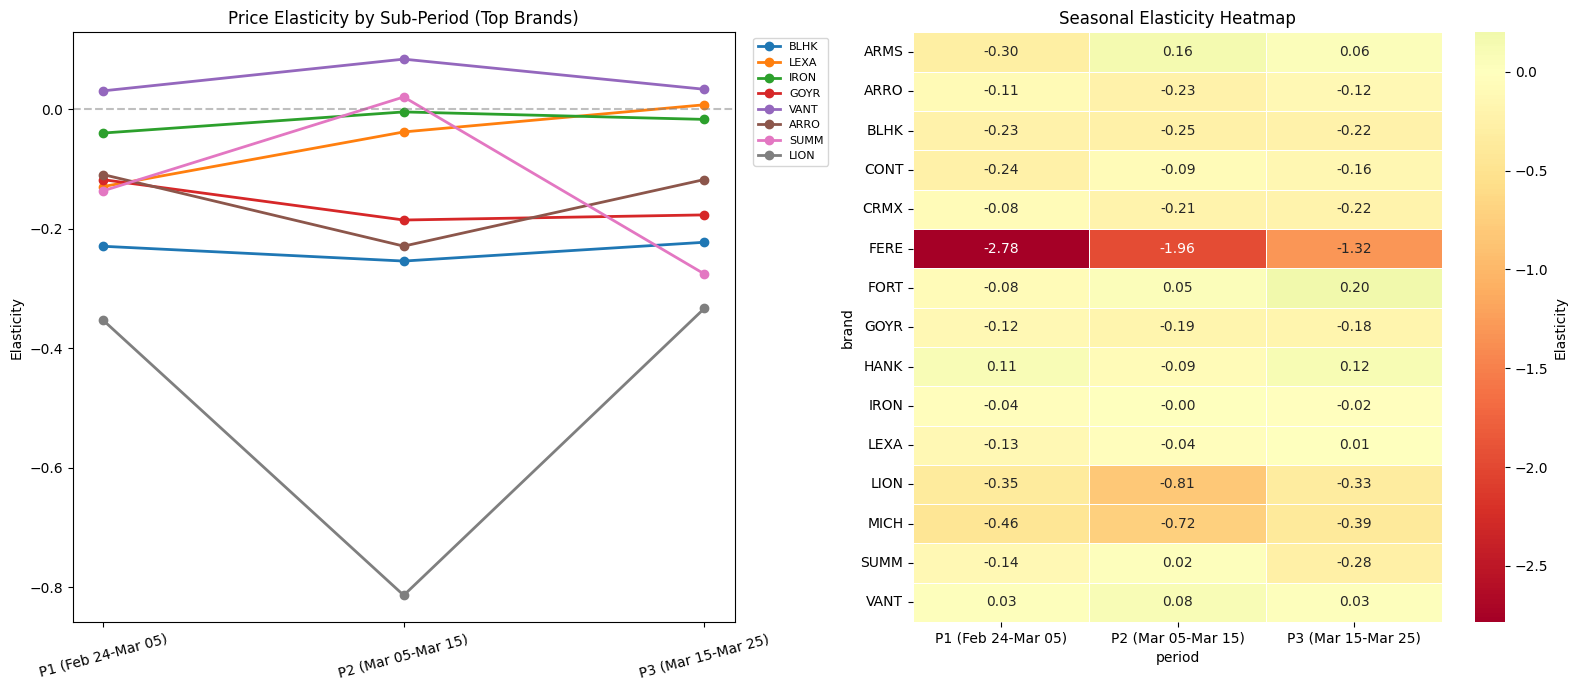


=== Brands with Largest Seasonal Elasticity Shift ===
  FERE: range = 1.468 (min=-2.784, max=-1.317)
  LION: range = 0.481 (min=-0.814, max=-0.333)
  ARMS: range = 0.459 (min=-0.296, max=0.164)
  MICH: range = 0.336 (min=-0.723, max=-0.387)
  SUMM: range = 0.297 (min=-0.276, max=0.021)


In [47]:
# --- Seasonal Visualization ---
# Line chart: elasticity by period per brand
brand_seasonal = df_seasonal[df_seasonal["brand"] != "ALL"].copy()

if len(brand_seasonal) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Line chart
    for brand in top_brands_s[:8]:  # top 8 for readability
        b_data = brand_seasonal[brand_seasonal["brand"] == brand].sort_values("period")
        if len(b_data) >= 2:
            axes[0].plot(b_data["period"], b_data["elasticity"], marker="o", label=brand, linewidth=2)
    axes[0].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    axes[0].set_title("Price Elasticity by Sub-Period (Top Brands)")
    axes[0].set_ylabel("Elasticity")
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    axes[0].tick_params(axis="x", rotation=15)

    # Heatmap
    pivot_s = brand_seasonal.pivot(index="brand", columns="period", values="elasticity")
    sns.heatmap(pivot_s, cmap="RdYlGn", center=0, annot=True, fmt=".2f",
                linewidths=0.5, ax=axes[1], cbar_kws={"label": "Elasticity"})
    axes[1].set_title("Seasonal Elasticity Heatmap")

    plt.tight_layout()
    plt.show()

    # Narrative: brands with largest seasonal shift
    brand_shift = brand_seasonal.groupby("brand")["elasticity"].agg(["min", "max"])
    brand_shift["range"] = brand_shift["max"] - brand_shift["min"]
    top_shifters = brand_shift.nlargest(5, "range")
    print("\n=== Brands with Largest Seasonal Elasticity Shift ===")
    for brand, r in top_shifters.iterrows():
        print(f"  {brand}: range = {r['range']:.3f} (min={r['min']:.3f}, max={r['max']:.3f})")
else:
    print("Insufficient data for seasonal brand-level visualization.")


## 19. Brand Price Sensitivity Rankings

Ranked table of brands by price elasticity with strategic recommendations.
- **Inelastic** (elasticity closer to 0): candidates for price **increases**
- **Elastic** (large negative elasticity): candidates for price **decreases** to capture volume

In [48]:
# --- Brand Sensitivity Rankings with Recommendations ---
MIN_OBS_BRAND = 30

all_brand_elast = []
for brand, grp in df_elast.groupby("brand"):
    if len(grp) < MIN_OBS_BRAND:
        continue
    try:
        X = sm.add_constant(np.log(grp["offer_price"]))
        y = np.log1p(grp["qty_sold"])
        model = sm.OLS(y, X).fit()
        all_brand_elast.append({
            "brand": brand, "elasticity": model.params.iloc[-1],
            "SE": model.bse.iloc[-1], "p_value": model.pvalues.iloc[-1], "n_obs": len(grp),
        })
    except Exception:
        continue

df_brand_rank = pd.DataFrame(all_brand_elast).sort_values("elasticity")

# Add context columns from the full dataset
brand_stats = df.groupby("brand").agg(
    avg_te_margin=("te_margin", "mean"),
    avg_wm_margin=("walmart_margin", "mean"),
    total_qty=("qty_sold", "sum"),
    total_revenue=("revenue", "sum"),
    n_sku_nodes=("SKU_Node", "nunique"),
).reset_index()
df_brand_rank = df_brand_rank.merge(brand_stats, on="brand", how="left")

# Classify sensitivity tier
def _classify(e):
    if e < -1.5: return "Highly Elastic"
    if e < -0.8: return "Elastic"
    if e < -0.3: return "Unit Elastic"
    return "Inelastic"

df_brand_rank["sensitivity_tier"] = df_brand_rank["elasticity"].apply(_classify)

# Recommendation
def _recommend(e):
    if e < -0.8: return "Decrease price to capture volume"
    if e > -0.3: return "Increase price to capture margin"
    return "Monitor - near unit elastic"

df_brand_rank["recommendation"] = df_brand_rank["elasticity"].apply(_recommend)

# Display
print(f"Brands with valid elasticity estimates: {len(df_brand_rank)}")
display(df_brand_rank.style.format({
    "elasticity": "{:.4f}", "SE": "{:.4f}", "p_value": "{:.4f}",
    "avg_te_margin": "{:.1%}", "avg_wm_margin": "{:.1%}",
    "total_qty": "{:,.0f}", "total_revenue": "${:,.0f}",
}).background_gradient(subset=["elasticity"], cmap="RdYlGn"))

# Top candidates
increase = df_brand_rank[df_brand_rank["recommendation"].str.contains("Increase")].head(5)
decrease = df_brand_rank[df_brand_rank["recommendation"].str.contains("Decrease")].head(5)

print("\n=== TOP 5 PRICE INCREASE CANDIDATES (Inelastic) ===")
for _, r in increase.iterrows():
    print(f"  {r['brand']}: elasticity={r['elasticity']:.3f}, current TE margin={r['avg_te_margin']:.1%}, qty={r['total_qty']:,.0f}")

print("\n=== TOP 5 PRICE DECREASE CANDIDATES (Elastic) ===")
for _, r in decrease.iterrows():
    print(f"  {r['brand']}: elasticity={r['elasticity']:.3f}, current TE margin={r['avg_te_margin']:.1%}, qty={r['total_qty']:,.0f}")


Brands with valid elasticity estimates: 130


,brand,elasticity,SE,p_value,n_obs,avg_te_margin,avg_wm_margin,total_qty,total_revenue,n_sku_nodes,sensitivity_tier,recommendation
0,PANT,-1.9084,0.3603,0.0000,95,13.0%,12.8%,"1,466","$67,354",15,Highly Elastic,Decrease price to capture volume
1,MONT,-1.4421,0.2658,0.0000,374,10.0%,-0.7%,"3,151","$196,255",65,Elastic,Decrease price to capture volume
2,LAUF,-1.2226,0.1434,0.0000,209,9.9%,-4.4%,"1,070","$83,015",115,Elastic,Decrease price to capture volume
3,SCPT,-1.0157,0.1576,0.0000,94,12.9%,13.2%,356,"$23,162",34,Elastic,Decrease price to capture volume
4,FERE,-0.9921,0.1584,0.0000,900,10.9%,11.1%,"11,932","$558,860",118,Elastic,Decrease price to capture volume
5,ADVN,-0.5288,0.1181,0.0000,199,10.7%,9.0%,629,"$51,352",82,Unit Elastic,Monitor - near unit elastic
6,DUNL,-0.5035,0.1149,0.0000,265,11.2%,8.5%,"1,427","$106,932",66,Unit Elastic,Monitor - near unit elastic
7,DURM,-0.4523,0.5347,0.4015,54,9.8%,-0.5%,274,"$42,795",7,Unit Elastic,Monitor - near unit elastic
8,VERS,-0.4500,0.0956,0.0000,186,8.4%,11.9%,"1,191","$96,828",25,Unit Elastic,Monitor - near unit elastic
9,BRID,-0.4244,0.0248,0.0000,2683,10.3%,12.7%,"10,113","$1,798,072",1515,Unit Elastic,Monitor - near unit elastic



=== TOP 5 PRICE INCREASE CANDIDATES (Inelastic) ===
  TRAI: elasticity=-0.293, current TE margin=12.6%, qty=1,532
  PETL: elasticity=-0.259, current TE margin=11.6%, qty=387
  CONT: elasticity=-0.245, current TE margin=12.1%, qty=15,954
  FORC: elasticity=-0.237, current TE margin=11.3%, qty=1,381
  RBPO: elasticity=-0.217, current TE margin=11.0%, qty=1,738

=== TOP 5 PRICE DECREASE CANDIDATES (Elastic) ===
  PANT: elasticity=-1.908, current TE margin=13.0%, qty=1,466
  MONT: elasticity=-1.442, current TE margin=10.0%, qty=3,151
  LAUF: elasticity=-1.223, current TE margin=9.9%, qty=1,070
  SCPT: elasticity=-1.016, current TE margin=12.9%, qty=356
  FERE: elasticity=-0.992, current TE margin=10.9%, qty=11,932


## 20. Optimal Margin Targeting

For each brand, estimate the TE margin and Walmart margin that maximize revenue or profit.
Fit a quadratic relationship: `qty ~ margin + margin²` to capture the inverted-U shape.

In [49]:
# --- Margin-Sales Relationship by Brand ---
top_brands_margin = df_brand_rank["brand"].head(20).tolist() if len(df_brand_rank) > 0 else top_brands_elast

margin_opt_results = []
df_margin = df[(df["qty_sold"] > 0) & (df["te_margin"].notna()) & (df["te_margin"].between(-0.5, 0.8))].copy()

for brand in top_brands_margin:
    b_data = df_margin[df_margin["brand"] == brand]
    if len(b_data) < 50:
        continue

    for margin_col, margin_name in [("te_margin", "TE Margin"), ("walmart_margin", "Walmart Margin")]:
        b_valid = b_data[b_data[margin_col].notna() & b_data[margin_col].between(-0.5, 0.8)]
        if len(b_valid) < 50:
            continue
        try:
            m = b_valid[margin_col].values
            m2 = m ** 2
            X = sm.add_constant(np.column_stack([m, m2]))
            y = b_valid["qty_sold"].values
            model = sm.OLS(y, X).fit()

            # Vertex of parabola: optimal = -b1 / (2*b2)
            b1, b2 = model.params[1], model.params[2]
            if b2 != 0:
                optimal = -b1 / (2 * b2)
                # Only report if optimal is in a reasonable range
                if -0.1 <= optimal <= 0.5:
                    margin_opt_results.append({
                        "brand": brand, "margin_type": margin_name,
                        "optimal_margin": optimal,
                        "current_avg": b_valid[margin_col].mean(),
                        "gap_pct": optimal - b_valid[margin_col].mean(),
                        "b1": b1, "b2": b2, "R2": model.rsquared,
                        "n_obs": len(b_valid), "is_concave": b2 < 0,
                    })
        except Exception:
            continue

df_margin_opt = pd.DataFrame(margin_opt_results)
if len(df_margin_opt) > 0:
    print("=== Optimal Margin Estimates (Quadratic Fit) ===")
    print("Note: 'is_concave=True' means the relationship has a peak (inverted-U).\n")
    display(df_margin_opt.style.format({
        "optimal_margin": "{:.1%}", "current_avg": "{:.1%}", "gap_pct": "{:+.1%}",
        "b1": "{:.4f}", "b2": "{:.4f}", "R2": "{:.4f}",
    }))

    # Flag brands where current margin is far from optimal
    big_gaps = df_margin_opt[(df_margin_opt["gap_pct"].abs() > 0.03) & df_margin_opt["is_concave"]]
    if len(big_gaps) > 0:
        print("\n=== Brands with >3pp Gap from Optimal Margin ===")
        for _, r in big_gaps.iterrows():
            direction = "increase" if r["gap_pct"] > 0 else "decrease"
            print(f"  {r['brand']} ({r['margin_type']}): optimal={r['optimal_margin']:.1%}, "
                  f"current={r['current_avg']:.1%} -> {direction} by {abs(r['gap_pct']):.1%}")
else:
    print("No brands with valid quadratic margin-sales fit in reasonable range.")


=== Optimal Margin Estimates (Quadratic Fit) ===
Note: 'is_concave=True' means the relationship has a peak (inverted-U).



,brand,margin_type,optimal_margin,current_avg,gap_pct,b1,b2,R2,n_obs,is_concave
0,PANT,TE Margin,16.1%,11.5%,+4.6%,985.1431,-3060.6979,0.0843,72,True
1,PANT,Walmart Margin,14.2%,13.2%,+0.9%,-308.8257,1089.4708,0.2046,72,False
2,MONT,TE Margin,19.4%,11.3%,+8.1%,104.2188,-269.1437,0.0315,360,True
3,MONT,Walmart Margin,5.2%,-6.6%,+11.7%,-3.0905,29.9726,0.0268,360,False
4,SCPT,TE Margin,18.7%,14.2%,+4.4%,-21.4716,57.4479,0.0107,65,False
5,SCPT,Walmart Margin,28.4%,13.7%,+14.7%,-8.3732,14.7417,0.0837,65,False
6,FERE,TE Margin,7.9%,12.2%,-4.4%,-62.9182,399.8151,0.0095,867,False
7,FERE,Walmart Margin,38.7%,14.8%,+23.8%,69.9724,-90.4784,0.0402,867,True
8,ADVN,TE Margin,9.8%,11.1%,-1.3%,-1.5129,7.7139,0.0023,162,False
9,DUNL,TE Margin,17.0%,11.5%,+5.5%,57.2586,-168.6892,0.0377,174,True



=== Brands with >3pp Gap from Optimal Margin ===
  PANT (TE Margin): optimal=16.1%, current=11.5% -> increase by 4.6%
  MONT (TE Margin): optimal=19.4%, current=11.3% -> increase by 8.1%
  FERE (Walmart Margin): optimal=38.7%, current=14.8% -> increase by 23.8%
  DUNL (TE Margin): optimal=17.0%, current=11.5% -> increase by 5.5%
  DUNL (Walmart Margin): optimal=19.1%, current=13.3% -> increase by 5.8%
  DURM (Walmart Margin): optimal=-2.9%, current=0.1% -> decrease by 3.1%
  BRID (TE Margin): optimal=35.0%, current=11.2% -> increase by 23.8%
  BRID (Walmart Margin): optimal=47.5%, current=15.3% -> increase by 32.1%
  POWE (TE Margin): optimal=14.2%, current=11.0% -> increase by 3.2%
  FORC (Walmart Margin): optimal=31.3%, current=1.0% -> increase by 30.3%


=== Revenue-Maximizing vs Profit-Maximizing TE Margin ===



,brand,rev_max_margin,profit_max_margin,current_avg,rev_vs_profit_gap
0,PANT,16.1%,16.9%,11.5%,-0.8%
1,MONT,19.4%,36.8%,11.3%,-17.4%
2,SCPT,18.7%,5.1%,14.2%,+13.6%
3,DUNL,17.0%,22.8%,11.5%,-5.9%
4,DURM,9.4%,6.5%,9.3%,+2.9%
5,VERS,12.2%,-0.1%,10.0%,+12.3%
6,POWE,14.2%,15.9%,11.0%,-1.7%
7,LION,14.5%,24.6%,12.0%,-10.1%
8,DORA,19.0%,8.9%,11.7%,+10.1%
9,TRAI,11.0%,20.1%,12.2%,-9.1%


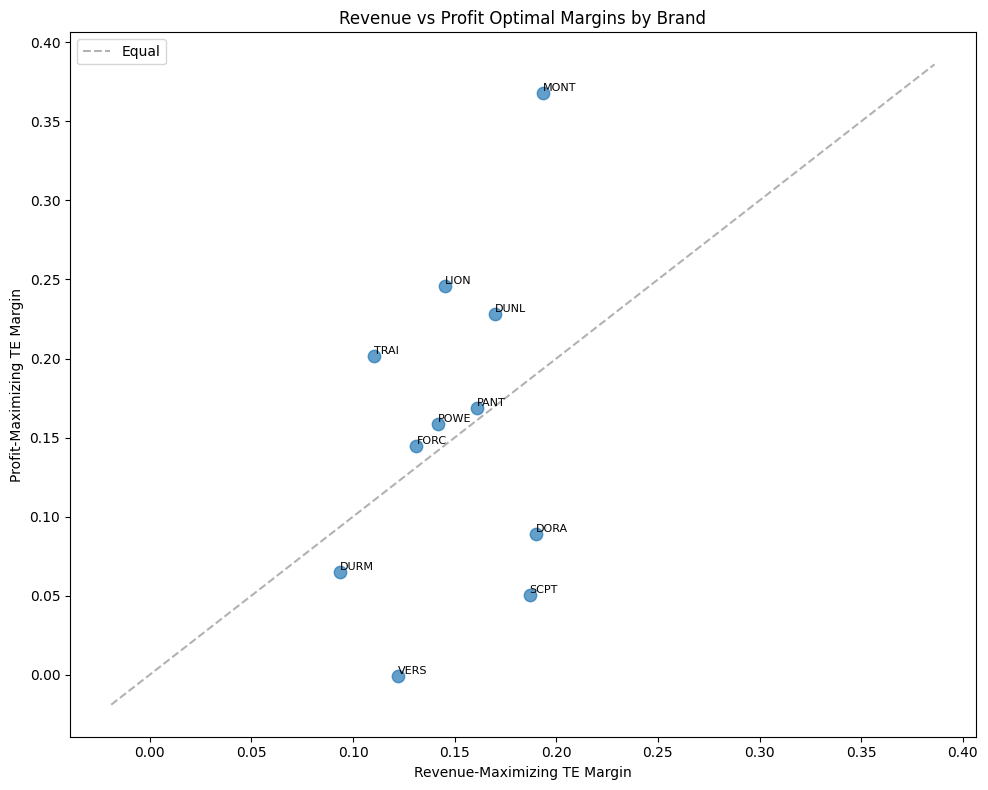

In [50]:
# --- Profit-Maximizing Margin ---
profit_opt_results = []

for brand in top_brands_margin:
    b_data = df_margin[df_margin["brand"] == brand]
    if len(b_data) < 50:
        continue
    b_valid = b_data[b_data["te_margin"].notna() & b_data["cost_to_walmart"].notna()].copy()
    if len(b_valid) < 50:
        continue

    # Profit proxy: qty * te_margin * cost_to_walmart
    b_valid["profit_proxy"] = b_valid["qty_sold"] * b_valid["te_margin"] * b_valid["cost_to_walmart"]

    try:
        m = b_valid["te_margin"].values
        X = sm.add_constant(np.column_stack([m, m ** 2]))
        y = b_valid["profit_proxy"].values
        model = sm.OLS(y, X).fit()
        b1, b2 = model.params[1], model.params[2]
        if b2 != 0:
            optimal_profit = -b1 / (2 * b2)
            if -0.1 <= optimal_profit <= 0.5:
                profit_opt_results.append({
                    "brand": brand,
                    "profit_max_margin": optimal_profit,
                    "current_avg": b_valid["te_margin"].mean(),
                    "is_concave": b2 < 0,
                    "R2": model.rsquared,
                })
    except Exception:
        continue

df_profit_opt = pd.DataFrame(profit_opt_results)

# Compare revenue-maximizing vs profit-maximizing
if len(df_profit_opt) > 0 and len(df_margin_opt) > 0:
    te_rev = df_margin_opt[df_margin_opt["margin_type"] == "TE Margin"][["brand", "optimal_margin"]].rename(
        columns={"optimal_margin": "rev_max_margin"})
    comparison = te_rev.merge(df_profit_opt[["brand", "profit_max_margin", "current_avg"]], on="brand")
    comparison["rev_vs_profit_gap"] = comparison["rev_max_margin"] - comparison["profit_max_margin"]

    print("=== Revenue-Maximizing vs Profit-Maximizing TE Margin ===\n")
    display(comparison.style.format({
        "rev_max_margin": "{:.1%}", "profit_max_margin": "{:.1%}",
        "current_avg": "{:.1%}", "rev_vs_profit_gap": "{:+.1%}",
    }))

    # Scatter plot
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(comparison["rev_max_margin"], comparison["profit_max_margin"], s=80, alpha=0.7)
    for _, r in comparison.iterrows():
        ax.annotate(r["brand"], (r["rev_max_margin"], r["profit_max_margin"]),
                    fontsize=8, ha="left", va="bottom")
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, "k--", alpha=0.3, label="Equal")
    ax.set_xlabel("Revenue-Maximizing TE Margin")
    ax.set_ylabel("Profit-Maximizing TE Margin")
    ax.set_title("Revenue vs Profit Optimal Margins by Brand")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for profit-maximizing comparison.")


## 21. What-If Price Change Simulation

Simulate gradual price changes (-5% to +5%) for each brand using estimated elasticity.
- **Elastic brands:** simulate price decreases to capture volume
- **Inelastic brands:** simulate price increases to capture margin

Identify diminishing returns.

In [51]:
# --- Simulation Engine ---
if len(df_brand_rank) > 0:
    pct_changes = np.arange(-0.05, 0.06, 0.01)

    sim_results = []
    for _, br in df_brand_rank.iterrows():
        brand = br["brand"]
        elast = br["elasticity"]
        # Baseline from actual data
        b_data = df[(df["brand"] == brand) & (df["qty_sold"] > 0)]
        if len(b_data) < 30:
            continue
        base_price = b_data["offer_price"].mean()
        base_qty = b_data["qty_sold"].mean()
        base_revenue = base_qty * base_price
        base_cost = b_data["cost_to_walmart"].mean() if "cost_to_walmart" in b_data.columns else base_price * 0.85
        base_profit = base_qty * (base_price - base_cost)

        for pct in pct_changes:
            new_price = base_price * (1 + pct)
            # Constant elasticity model: Q_new = Q_base * (P_new / P_base) ^ elasticity
            if base_price > 0:
                projected_qty = base_qty * (new_price / base_price) ** elast
            else:
                projected_qty = base_qty
            projected_revenue = projected_qty * new_price
            projected_profit = projected_qty * (new_price - base_cost)

            sim_results.append({
                "brand": brand, "pct_change": pct,
                "new_price": new_price, "projected_qty": projected_qty,
                "projected_revenue": projected_revenue, "projected_profit": projected_profit,
                "revenue_change_pct": (projected_revenue - base_revenue) / base_revenue if base_revenue > 0 else 0,
                "profit_change_pct": (projected_profit - base_profit) / base_profit if base_profit > 0 else 0,
                "base_revenue": base_revenue, "base_profit": base_profit,
            })

    df_sim = pd.DataFrame(sim_results)
    print(f"Simulation complete: {df_sim['brand'].nunique()} brands, {len(pct_changes)} price points each")
    print(f"Total simulation rows: {len(df_sim):,}")
else:
    df_sim = pd.DataFrame()
    print("No brand elasticity data available for simulation.")


Simulation complete: 130 brands, 11 price points each
Total simulation rows: 1,430


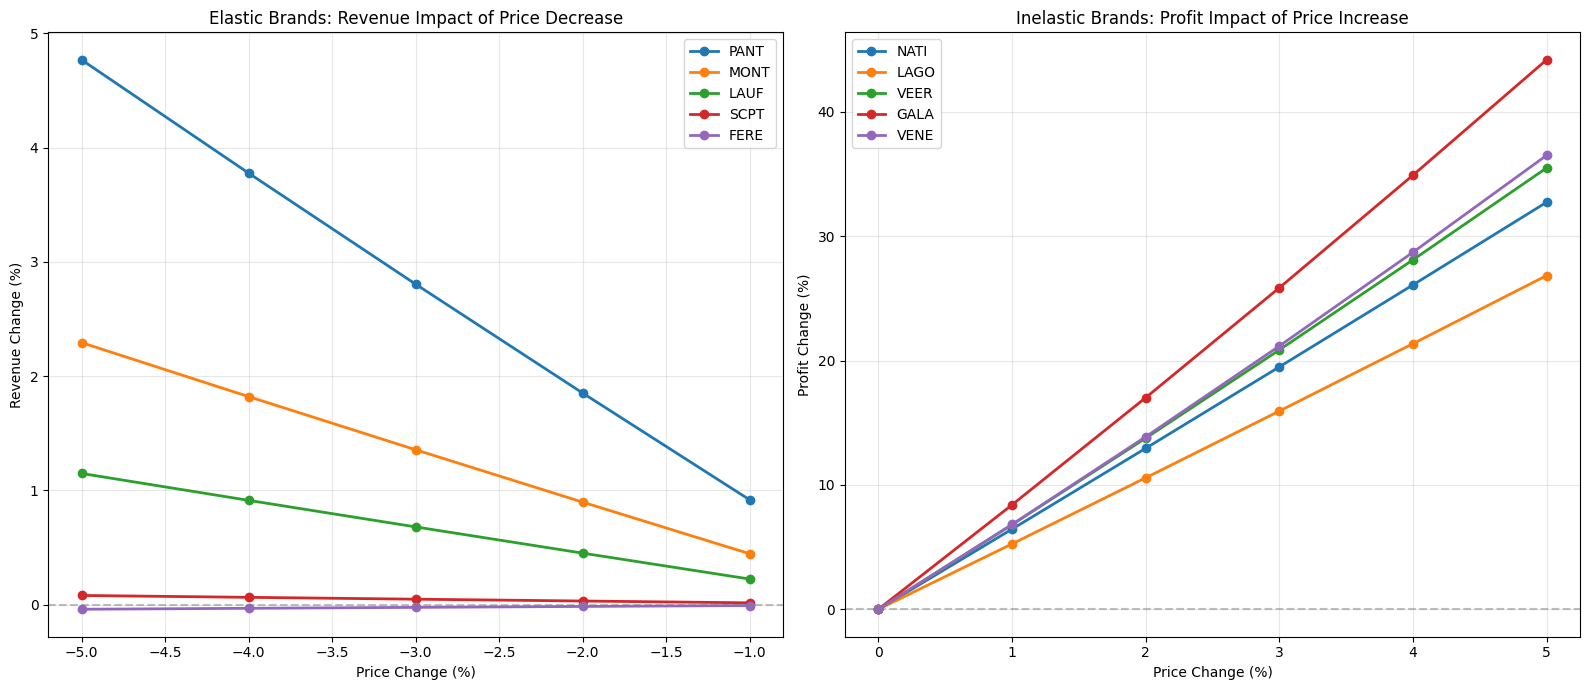


=== Recommended Price Changes (Sweet Spot) ===


,brand,strategy,recommended_pct,expected_revenue_chg,expected_profit_chg
0,PANT,Decrease price,-5%,+4.8%,-
1,MONT,Decrease price,-5%,+2.3%,-
2,LAUF,Decrease price,-5%,+1.1%,-
3,SCPT,Decrease price,-5%,+0.1%,-
4,FERE,Decrease price,-1%,-0.0%,-
5,TRAI,Increase price,+5%,-,+37.9%
6,PETL,Increase price,+5%,-,+28.8%
7,CONT,Increase price,+5%,-,+34.8%
8,FORC,Increase price,+5%,-,+324.1%
9,RBPO,Increase price,+5%,-,+33.3%


In [52]:
# --- Visualization & Diminishing Returns ---
if len(df_sim) > 0:
    elastic_brands = df_brand_rank[df_brand_rank["elasticity"] < -0.8]["brand"].head(5).tolist()
    inelastic_brands = df_brand_rank[df_brand_rank["elasticity"] > -0.3]["brand"].tail(5).tolist()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Elastic brands: revenue impact of price decreases
    for brand in elastic_brands:
        b_sim = df_sim[(df_sim["brand"] == brand) & (df_sim["pct_change"] <= 0)].sort_values("pct_change")
        if len(b_sim) > 0:
            axes[0].plot(b_sim["pct_change"] * 100, b_sim["revenue_change_pct"] * 100,
                        marker="o", label=brand, linewidth=2)
    axes[0].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    axes[0].set_title("Elastic Brands: Revenue Impact of Price Decrease")
    axes[0].set_xlabel("Price Change (%)")
    axes[0].set_ylabel("Revenue Change (%)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Inelastic brands: profit impact of price increases
    for brand in inelastic_brands:
        b_sim = df_sim[(df_sim["brand"] == brand) & (df_sim["pct_change"] >= 0)].sort_values("pct_change")
        if len(b_sim) > 0:
            axes[1].plot(b_sim["pct_change"] * 100, b_sim["profit_change_pct"] * 100,
                        marker="o", label=brand, linewidth=2)
    axes[1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    axes[1].set_title("Inelastic Brands: Profit Impact of Price Increase")
    axes[1].set_xlabel("Price Change (%)")
    axes[1].set_ylabel("Profit Change (%)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Diminishing returns: find sweet spot per brand
    sweet_spot = []
    for brand in df_sim["brand"].unique():
        b_sim = df_sim[df_sim["brand"] == brand].sort_values("pct_change")
        b_sim["marginal_profit"] = b_sim["projected_profit"].diff() / (b_sim["pct_change"].diff() * b_sim["base_profit"].iloc[0]) if b_sim["base_profit"].iloc[0] != 0 else 0

        elast = df_brand_rank[df_brand_rank["brand"] == brand]["elasticity"].iloc[0]
        if elast < -0.8:  # elastic -> look at decreases
            decreases = b_sim[b_sim["pct_change"] < 0].sort_values("pct_change", ascending=False)
            best_pct = decreases.loc[decreases["revenue_change_pct"].idxmax(), "pct_change"] if len(decreases) > 0 else 0
            best_rev = decreases["revenue_change_pct"].max() if len(decreases) > 0 else 0
            sweet_spot.append({"brand": brand, "strategy": "Decrease price",
                               "recommended_pct": best_pct, "expected_revenue_chg": best_rev})
        elif elast > -0.3:  # inelastic -> look at increases
            increases = b_sim[b_sim["pct_change"] > 0].sort_values("pct_change")
            best_pct = increases.loc[increases["profit_change_pct"].idxmax(), "pct_change"] if len(increases) > 0 else 0
            best_prof = increases["profit_change_pct"].max() if len(increases) > 0 else 0
            sweet_spot.append({"brand": brand, "strategy": "Increase price",
                               "recommended_pct": best_pct, "expected_profit_chg": best_prof})

    df_sweet = pd.DataFrame(sweet_spot)
    if len(df_sweet) > 0:
        print("\n=== Recommended Price Changes (Sweet Spot) ===")
        display(df_sweet.style.format({
            "recommended_pct": "{:+.0%}",
            "expected_revenue_chg": "{:+.1%}",
            "expected_profit_chg": "{:+.1%}",
        }, na_rep="-"))
else:
    print("No simulation data available.")


## 22. Actionable Pricing Strategy by Brand-State Segment

Capstone section combining elasticity, treatment effects, margin analysis, and simulation
into per-segment recommendations.

In [53]:
# --- Build Master Strategy Table ---
strategy_rows = []

# Use brand-state elasticity from §16
if len(df_bs_elast) > 0 and len(df_brand_rank) > 0:
    bs_valid = df_bs_elast.dropna(subset=["elasticity"]).copy()

    for _, r in bs_valid.iterrows():
        brand, state = r["brand"], r["State"]
        elast = r["elasticity"]
        n = r["n"]
        pval = r["p_value"]

        # Get brand-level info
        br_info = df_brand_rank[df_brand_rank["brand"] == brand]
        avg_te = br_info["avg_te_margin"].iloc[0] if len(br_info) > 0 else np.nan
        avg_wm = br_info["avg_wm_margin"].iloc[0] if len(br_info) > 0 else np.nan

        # Get treatment effect if available
        att = np.nan
        if len(df_het) > 0:
            brand_het = df_het[(df_het["segment_type"] == "Brand") & (df_het["segment_value"] == brand)]
            if len(brand_het) > 0:
                att = brand_het["ATT"].iloc[0]

        # Get optimal margin if available
        opt_margin = np.nan
        if len(df_margin_opt) > 0:
            opt = df_margin_opt[(df_margin_opt["brand"] == brand) & (df_margin_opt["margin_type"] == "TE Margin")]
            if len(opt) > 0:
                opt_margin = opt["optimal_margin"].iloc[0]

        # Recommendation logic
        if elast < -0.8:
            action = "Decrease"
            rec_pct = max(-0.05, elast * 0.02)  # conservative: small fraction of elasticity
        elif elast > -0.3:
            action = "Increase"
            rec_pct = min(0.05, abs(elast) * 0.03)
        else:
            action = "Hold"
            rec_pct = 0.0

        # Projected impact (using constant elasticity)
        expected_qty_pct = (1 + rec_pct) ** elast - 1 if rec_pct != 0 else 0
        expected_rev_pct = ((1 + rec_pct) * (1 + expected_qty_pct)) - 1

        # Confidence
        if pval < 0.01 and n > 200:
            confidence = "High"
        elif pval < 0.05 and n > 50:
            confidence = "Medium"
        else:
            confidence = "Low"

        strategy_rows.append({
            "brand": brand, "State": state, "elasticity": elast,
            "treatment_effect": att, "optimal_te_margin": opt_margin,
            "current_te_margin": avg_te, "current_wm_margin": avg_wm,
            "action": action, "recommended_change": rec_pct,
            "expected_qty_impact": expected_qty_pct,
            "expected_revenue_impact": expected_rev_pct,
            "confidence": confidence, "n_obs": n, "p_value": pval,
        })

df_strategy = pd.DataFrame(strategy_rows)
if len(df_strategy) > 0:
    # Sort by expected revenue impact
    df_strategy = df_strategy.sort_values("expected_revenue_impact", ascending=False)
    print(f"Strategy table: {len(df_strategy)} brand-state segments")
    display(df_strategy.head(20).style.format({
        "elasticity": "{:.3f}", "treatment_effect": "{:+.4f}",
        "optimal_te_margin": "{:.1%}", "current_te_margin": "{:.1%}", "current_wm_margin": "{:.1%}",
        "recommended_change": "{:+.1%}", "expected_qty_impact": "{:+.1%}",
        "expected_revenue_impact": "{:+.1%}", "p_value": "{:.4f}",
    }, na_rep="-").background_gradient(subset=["expected_revenue_impact"], cmap="RdYlGn"))
else:
    print("Insufficient data to build strategy table.")


Strategy table: 171 brand-state segments


,brand,State,elasticity,treatment_effect,optimal_te_margin,current_te_margin,current_wm_margin,action,recommended_change,expected_qty_impact,expected_revenue_impact,confidence,n_obs,p_value
65,VANT,US-AZ,0.493,+0.0402,-,12.1%,16.0%,Increase,+1.5%,+0.7%,+2.2%,Medium,240,0.0409
161,ARMS,US-NC,0.299,-,-,11.6%,13.5%,Increase,+0.9%,+0.3%,+1.2%,Low,43,0.1706
51,GOYR,US-MN,0.283,-0.0273,-,11.0%,12.0%,Increase,+0.8%,+0.2%,+1.1%,Medium,409,0.0137
139,FERE,US-CA,-1.367,-,7.9%,10.9%,11.1%,Decrease,-2.7%,+3.9%,+1.0%,Medium,136,0.0233
36,IRON,US-MN,0.258,-2.2640,-,12.0%,9.9%,Increase,+0.8%,+0.2%,+1.0%,High,215,0.0048
157,ARMS,US-TX,0.248,-,-,11.6%,13.5%,Increase,+0.7%,+0.2%,+0.9%,High,446,0.0001
143,MICH,US-CA,0.245,-,6.8%,11.0%,14.0%,Increase,+0.7%,+0.2%,+0.9%,Medium,178,0.0296
135,HANK,US-MN,0.227,-0.0241,-,10.8%,15.1%,Increase,+0.7%,+0.2%,+0.8%,Low,65,0.1569
67,VANT,US-NY,0.206,+0.0402,-,12.1%,16.0%,Increase,+0.6%,+0.1%,+0.7%,Medium,509,0.0472
134,HANK,US-AZ,0.203,-0.0241,-,10.8%,15.1%,Increase,+0.6%,+0.1%,+0.7%,Low,100,0.1492


In [54]:
# --- Narrative Summary ---
if len(df_strategy) > 0:
    print("=" * 70)
    print("ACTIONABLE PRICING RECOMMENDATIONS")
    print("=" * 70)

    # Top 10 highest-impact
    top10 = df_strategy.head(10)
    print("\n--- TOP 10 HIGHEST REVENUE IMPACT ---\n")
    for i, (_, r) in enumerate(top10.iterrows(), 1):
        sig = f"[{r['confidence']} confidence]"
        print(f"{i}. **{r['brand']} in {r['State']}** (elasticity={r['elasticity']:.3f}, n={r['n_obs']:,})")
        print(f"   {r['action']} price by {abs(r['recommended_change']):.0%} -> "
              f"Expected revenue: {r['expected_revenue_impact']:+.1%}, "
              f"Expected qty: {r['expected_qty_impact']:+.1%}  {sig}")

    # Quick wins: high confidence, positive revenue impact
    quick_wins = df_strategy[(df_strategy["confidence"] == "High") &
                              (df_strategy["expected_revenue_impact"] > 0)].head(5)
    if len(quick_wins) > 0:
        print("\n--- QUICK WINS (High Confidence, Positive Revenue) ---\n")
        for _, r in quick_wins.iterrows():
            print(f"  {r['brand']} in {r['State']}: {r['action']} {abs(r['recommended_change']):.0%} "
                  f"-> +{r['expected_revenue_impact']:.1%} revenue (n={r['n_obs']:,})")

    # Caution: low confidence or counter-intuitive
    caution = df_strategy[df_strategy["confidence"] == "Low"].head(5)
    if len(caution) > 0:
        print("\n--- CAUTION (Low Confidence - Need More Data) ---\n")
        for _, r in caution.iterrows():
            print(f"  {r['brand']} in {r['State']}: elasticity={r['elasticity']:.3f} "
                  f"(p={r['p_value']:.3f}, n={r['n_obs']:,}) — insufficient evidence")
else:
    print("No strategy recommendations available.")


ACTIONABLE PRICING RECOMMENDATIONS

--- TOP 10 HIGHEST REVENUE IMPACT ---

1. **VANT in US-AZ** (elasticity=0.493, n=240)
   Increase price by 1% -> Expected revenue: +2.2%, Expected qty: +0.7%  [Medium confidence]
2. **ARMS in US-NC** (elasticity=0.299, n=43)
   Increase price by 1% -> Expected revenue: +1.2%, Expected qty: +0.3%  [Low confidence]
3. **GOYR in US-MN** (elasticity=0.283, n=409)
   Increase price by 1% -> Expected revenue: +1.1%, Expected qty: +0.2%  [Medium confidence]
4. **FERE in US-CA** (elasticity=-1.367, n=136)
   Decrease price by 3% -> Expected revenue: +1.0%, Expected qty: +3.9%  [Medium confidence]
5. **IRON in US-MN** (elasticity=0.258, n=215)
   Increase price by 1% -> Expected revenue: +1.0%, Expected qty: +0.2%  [High confidence]
6. **ARMS in US-TX** (elasticity=0.248, n=446)
   Increase price by 1% -> Expected revenue: +0.9%, Expected qty: +0.2%  [High confidence]
7. **MICH in US-CA** (elasticity=0.245, n=178)
   Increase price by 1% -> Expected revenue: 

## 23. Extended Executive Summary

In [55]:
# --- Extended Executive Summary ---
print("=" * 70)
print("EXTENDED EXECUTIVE SUMMARY")
print(f"Analysis Window: {START_DATE} to {END_DATE}")
print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("=" * 70)

# New features
print("\n1. NEW FEATURES")
print(f"   - Tire size coverage: {df['tire_size'].notna().mean():.1%}")
print(f"   - MAP-governed tires: {df['is_MAP_tire'].mean():.1%}")
if df["tire_diameter"].notna().any():
    print(f"   - Most common diameters: {df['tire_diameter'].value_counts().head(5).to_dict()}")

# State elasticity
print("\n2. STATE-LEVEL PRICE SENSITIVITY")
if len(df_state_elast) > 0:
    most_sens = df_state_elast.iloc[0]
    least_sens = df_state_elast.iloc[-1]
    print(f"   - Most price-sensitive state: {most_sens['State']} (elasticity={most_sens['elasticity']:.3f})")
    print(f"   - Least price-sensitive state: {least_sens['State']} (elasticity={least_sens['elasticity']:.3f})")
    print(f"   - States analyzed: {len(df_state_elast)}")

# Brand-State highlights
print("\n3. BRAND-STATE HIGHLIGHTS")
if len(df_bs_elast) > 0:
    bs_valid = df_bs_elast.dropna(subset=["elasticity"])
    print(f"   - Brand-State segments analyzed: {len(bs_valid)}")
    if len(bs_valid) > 0:
        top = bs_valid.nsmallest(3, "elasticity")
        for _, r in top.iterrows():
            print(f"   - {r['brand']} in {r['State']}: elasticity={r['elasticity']:.3f} (highly sensitive)")

# Treatment effects
print("\n4. HETEROGENEOUS TREATMENT EFFECTS")
if len(df_het) > 0:
    map_effects = df_het[df_het["segment_type"] == "MAP Status"]
    if len(map_effects) > 0:
        for _, r in map_effects.iterrows():
            print(f"   - {r['segment_value']}: ATT={r['ATT']:+.4f}{r['sig']}")

# Seasonal
print("\n5. SEASONAL PRICE SENSITIVITY")
if len(df_seasonal) > 0:
    overall = df_seasonal[df_seasonal["brand"] == "ALL"]
    for _, r in overall.iterrows():
        print(f"   - {r['period']}: overall elasticity={r['elasticity']:.4f}")

# Strategy highlights
print("\n6. TOP RECOMMENDATIONS")
if len(df_strategy) > 0:
    n_increase = (df_strategy["action"] == "Increase").sum()
    n_decrease = (df_strategy["action"] == "Decrease").sum()
    n_hold = (df_strategy["action"] == "Hold").sum()
    print(f"   - {n_increase} segments: increase price")
    print(f"   - {n_decrease} segments: decrease price")
    print(f"   - {n_hold} segments: hold current price")
    high_conf = df_strategy[df_strategy["confidence"] == "High"]
    print(f"   - High-confidence recommendations: {len(high_conf)}")

print("\n" + "=" * 70)
print("END OF EXTENDED ANALYSIS")
print("=" * 70)


EXTENDED EXECUTIVE SUMMARY
Analysis Window: 2026-02-24 to 2026-03-25
Dataset: 7,663,410 rows, 41 columns

1. NEW FEATURES
   - Tire size coverage: 0.0%
   - MAP-governed tires: 19.5%

2. STATE-LEVEL PRICE SENSITIVITY
   - Most price-sensitive state: US-AZ (elasticity=-0.405)
   - Least price-sensitive state: US-VT (elasticity=0.115)
   - States analyzed: 46

3. BRAND-STATE HIGHLIGHTS
   - Brand-State segments analyzed: 171
   - FERE in US-CA: elasticity=-1.367 (highly sensitive)
   - MICH in US-MN: elasticity=-0.871 (highly sensitive)
   - MICH in US-NC: elasticity=-0.859 (highly sensitive)

4. HETEROGENEOUS TREATMENT EFFECTS
   - MAP Tire: ATT=-0.0115
   - Non-MAP: ATT=-0.0379

5. SEASONAL PRICE SENSITIVITY
   - P1 (Feb 24-Mar 05): overall elasticity=-0.0789
   - P2 (Mar 05-Mar 15): overall elasticity=-0.0748
   - P3 (Mar 15-Mar 25): overall elasticity=-0.0514

6. TOP RECOMMENDATIONS
   - 153 segments: increase price
   - 3 segments: decrease price
   - 15 segments: hold current price

## 24. Save & Cleanup

In [56]:
# Save the extended dataset (with new features)
project_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
output_dir = os.path.join(project_root, "outputs")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"correlation_dataset_{END_DATE}.parquet")
try:
    df.to_parquet(output_path, index=False)
    print(f"Dataset saved to {output_path}")
except Exception as e:
    output_path = output_path.replace(".parquet", ".csv")
    df.to_csv(output_path, index=False)
    print(f"Parquet failed ({e}), saved as CSV: {output_path}")

print(f"Shape: {df.shape}")

# Cleanup
try:
    loader.close()
except NameError:
    pass  # loader not available in cached mode
print("Done.")


Dataset saved to C:\Users\valen\Desktop\WalmartPricing\outputs\correlation_dataset_2026-03-25.parquet
Shape: (7663410, 41)
Done.
